#PRCP-1027: Skin Disease Classification
### Machine Learning Project | Healthcare Domain
---

---


**Problem Statement**

The differential diagnosis of erythemato-squamous diseases (skin diseases characterised by redness and scaling) is a challenging real-world problem in dermatology. These diseases share many clinical and histopathological features, making it difficult to distinguish them without a biopsy.

**Task**

(1) EDA Report

(2) Predictive Model

(3) Suggestions To Doctors

***Importing Requried Libraries***

In [ ]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,roc_curve, auc,roc_auc_score,precision_recall_fscore_support)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier
print("All libraries imported successfully!")

# --- Disease Name Map (used throughout notebook) ---
disease_map = {
    1: 'Psoriasis',
    2: 'Seborrheic Dermatitis',
    3: 'Lichen Planus',
    4: 'Pityriasis Rosea',
    5: 'Chronic Dermatitis',
    6: 'Pityriasis Rubra Pilaris'
}


All libraries imported successfully!


***Load Dataset***

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/PROJECT/P3/dataset_35_dermatology.csv')
print(f"Dataset loaded: {data.shape[0]} rows × {data.shape[1]} columns")
data

Dataset loaded: 366 rows × 35 columns


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


In [ ]:
data['family_history'].value_counts()

,count
family_history,
0,320
1,46


---
***Domain Analysis***
---

The 6 Target Classes:

* Psoriasis

* Seborrheic Dermatitis

* Lichen Planus

* Pityriasis Rosea

* Chronic Dermatitis

* Pityriasis Rubra Pilaris

###**Feature Categories:**

**Clinical Attributes (12 features)**: *These are things a doctor sees during an exam (e.g., itching, skin redness).*

**Histopathological Attributes (22 features)**: *These are microscopic details from a skin biopsy (e.g., changes in skin cells).*

**Demographics:** *Includes "Age" and "Family History."*

**Data Scaling:** *Almost all features are ranked on a scale of 0 to 3 (0 = absent, 3 = severe), except for Age.*


---
## Basic Checks

In [ ]:
data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [ ]:
data.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [ ]:
# Shape of the Data
data.shape

(366, 35)

In [ ]:
print("="*60)
print("Dataset Info")
print("="*60)
data.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                       

*Type Casting the AGE Feature(Object---->Float)*

In [ ]:
# Replacing '?' with NaN as ? is not a number
data['Age'] = data['Age'].replace('?',np.nan)
# Convert Age from string (object) to numeric (float64)
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')
# Verify how many missing values were created after replacing '?'
print("Missing values in Age:", data['Age'].isnull().sum())

Missing values in Age: 8


In [ ]:
data.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
erythema,366.000000,2.068306,0.664753,0.000000,2.000000,2.000000,2.000000,3.000000
scaling,366.000000,1.795082,0.701527,0.000000,1.000000,2.000000,2.000000,3.000000
definite_borders,366.000000,1.549180,0.907525,0.000000,1.000000,2.000000,2.000000,3.000000
itching,366.000000,1.366120,1.138299,0.000000,0.000000,1.000000,2.000000,3.000000
koebner_phenomenon,366.000000,0.633880,0.908016,0.000000,0.000000,0.000000,1.000000,3.000000
polygonal_papules,366.000000,0.448087,0.957327,0.000000,0.000000,0.000000,0.000000,3.000000
follicular_papules,366.000000,0.166667,0.570588,0.000000,0.000000,0.000000,0.000000,3.000000
oral_mucosal_involvement,366.000000,0.377049,0.834147,0.000000,0.000000,0.000000,0.000000,3.000000
knee_and_elbow_involvement,366.000000,0.614754,0.982979,0.000000,0.000000,0.000000,1.000000,3.000000
scalp_involvement,366.000000,0.519126,0.905639,0.000000,0.000000,0.000000,1.000000,3.000000


***Insights***

* Initial inspection showed the Age column had '?' characters. After converting to numeric, we found 8 missing values (out of 366 total rows).
* The patient age ranges from 0 to 75 years, with a median age of 35. This shows the dataset covers a wide demographic, from infants to seniors.
* All clinical/histopathological features are strictly within the 0 to 3 range, meaning no extreme outliers exist in the symptom data, only in the Age column.

---
## ***Exploratory Data Analysis***

***1) Univariate***

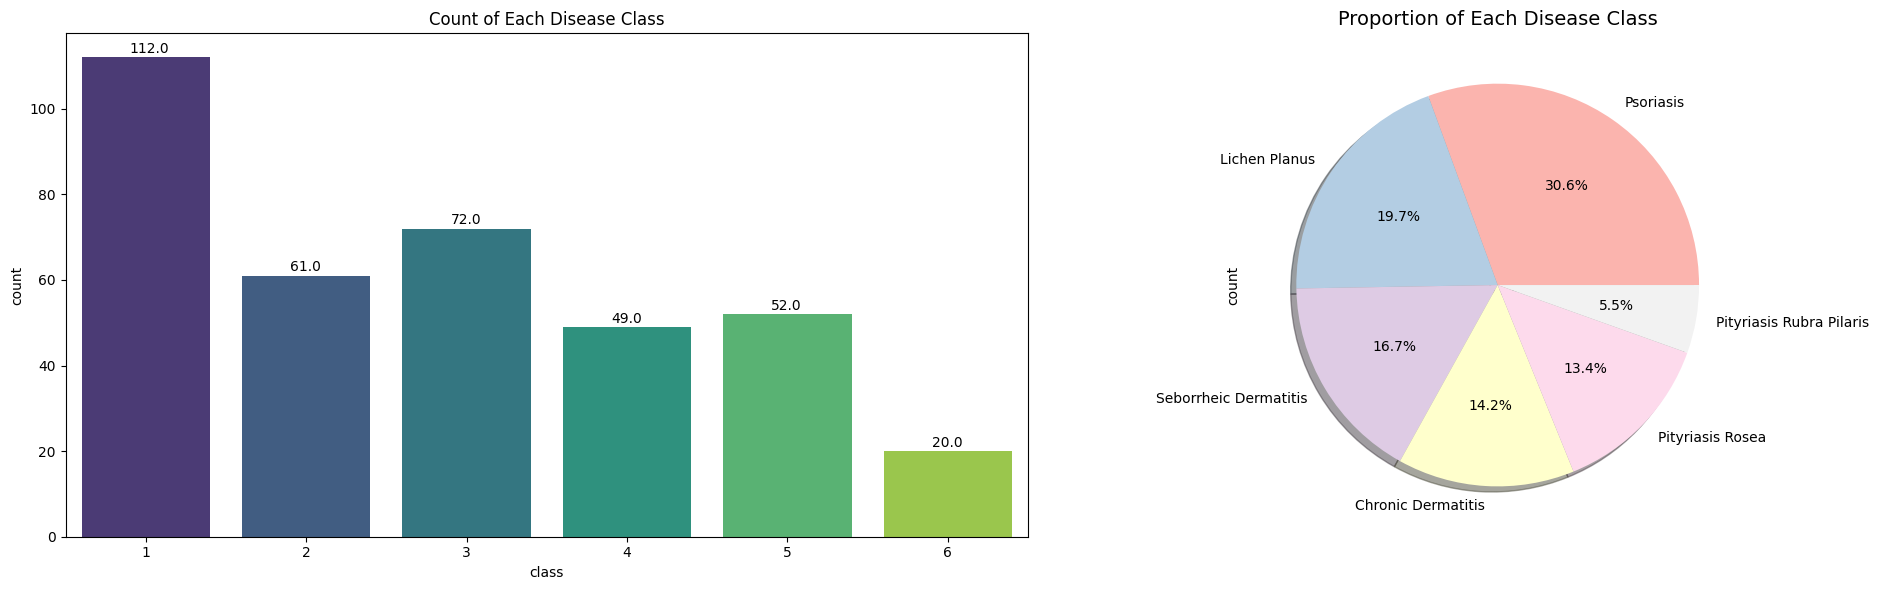

In [ ]:
# Target Class Analysis (The "Label" Distribution)
# Create a figure with two subplots: Bar chart and Pie chart
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Bar Chart
sns.countplot(x=data['class'], data=data, palette='viridis', ax=ax[0])
ax[0].set_title('Count of Each Disease Class', fontsize=12)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 1))

# Pie Chart
data['class'].map(disease_map).value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], shadow=True, cmap='Pastel1')
ax[1].set_title('Proportion of Each Disease Class', fontsize=14)

plt.tight_layout()
plt.show()

***Insights***

* Class 1 (Psoriasis) is nearly 5.6 times more frequent than Class 6 (PRP).
* If we use standard `Accuracy` as a metric, the model could ignore Class 6 and still get ~95% accuracy,
 so we must use `Stratified K-Fold` Cross-Validation and look at the `Macro-F1 Score` later.

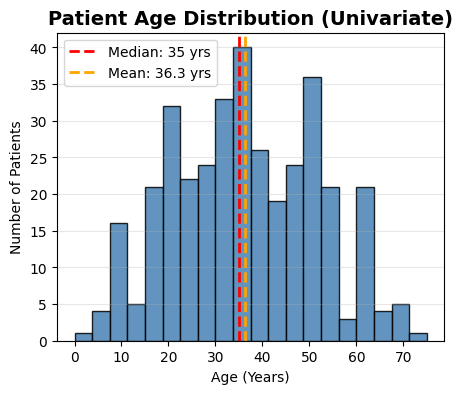

--- Age Column Statistics ---
Skewness: 0.073
Kurtosis: -0.708


In [ ]:
# Plotting the histogram for Age
plt.figure(figsize=(5, 4))

plt.hist(
    data['Age'].dropna(),  # We use dropna() to ensure the 8 missing values don't interfere with the calculation
    bins=20,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Adding statistical guide lines (Mean and Median)
# This shows the "Central Tendency" of your data
plt.axvline(
    data['Age'].median(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Median: {data['Age'].median():.0f} yrs"
)

plt.axvline(
    data['Age'].mean(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {data['Age'].mean():.1f} yrs"
)

# Labeling for clarity
plt.title('Patient Age Distribution (Univariate)', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Professional AI Engineering Stat Check
print(f"--- Age Column Statistics ---")
print(f"Skewness: {data['Age'].skew():.3f}")
print(f"Kurtosis: {data['Age'].kurtosis():.3f}")

***Insights***

* The Age distribution is nearly Normal (Symmetric), as the skewness is very low.
* The peak (mode) is around 30-40 years, indicating that these skin disorders are most commonly diagnosed in young to middle-aged adults.
* The Presence of age 0 indicates pediatric cases are also present in the study.

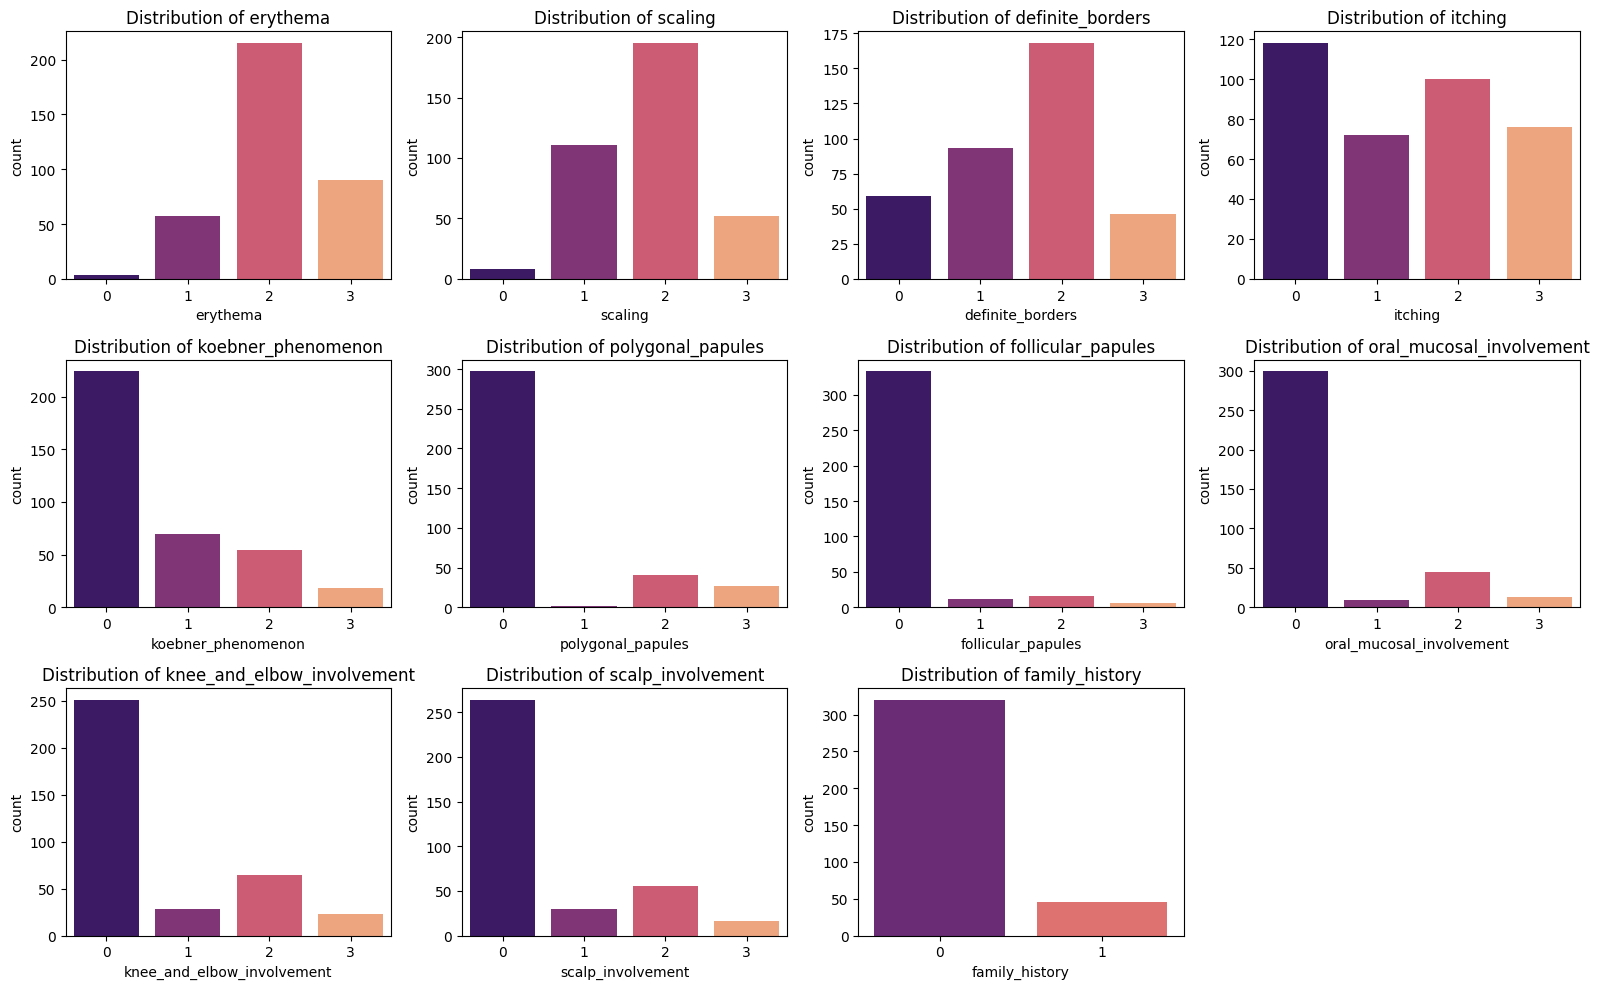

In [ ]:
# Selecting a subset of clinical features to show distribution
clinical_features = data.columns[:11]

plt.figure(figsize=(16, 10))
for i, col in enumerate(clinical_features):
    plt.subplot(3, 4, i+1)
    sns.countplot(x=col, data=data, palette='magma')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

***2) Bivariate***

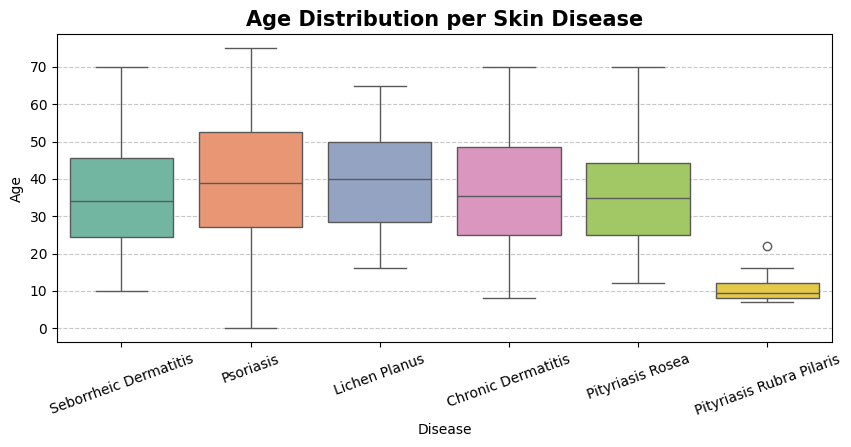

In [ ]:
plt.figure(figsize=(10, 4))

# Create a temporary dataframe with disease names for plotting
temp_df = data.copy()
temp_df['Disease'] = temp_df['class'].map(disease_map)

sns.boxplot(data=temp_df, x='Disease', y='Age', palette='Set2')

plt.title('Age Distribution per Skin Disease', fontsize=15, fontweight='bold')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*Insights*

* The boxplot shows that Class 4 (Pityriasis Rosea) and Class 2 (Seborrheic Dermatitis) have a lower median age compared to Class 1 (Psoriasis).
* This suggests Age is a statistically significant feature for classification.

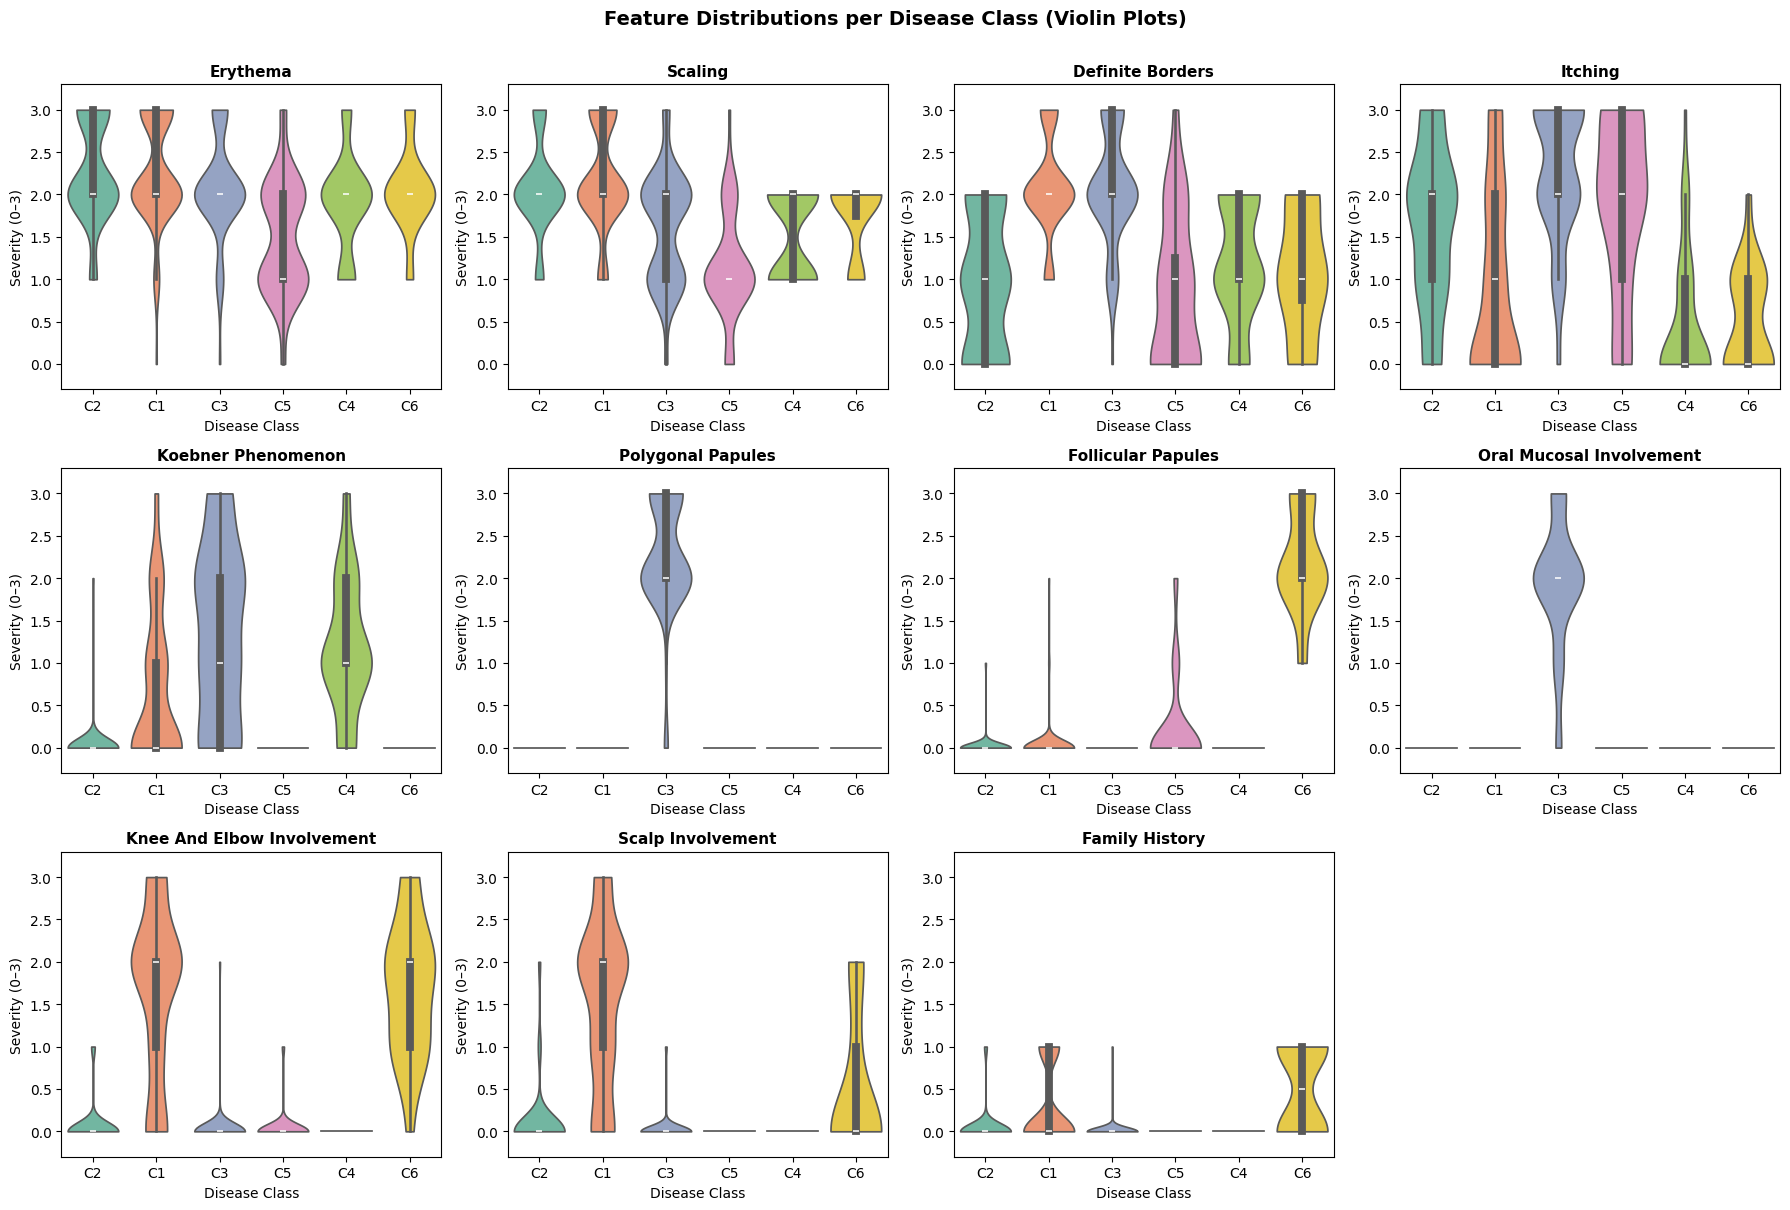

📊 Wide violin = many patients with that severity | Narrow = few patients


In [ ]:
# VIOLIN PLOTS: KEY FEATURES vs DISEASE CLASS (Clinical Features))

violin_features = data.columns[:11]

temp_viol = data.copy()
temp_viol['Disease'] = temp_viol['class'].map(lambda x: f"C{x}")
# lambda converts class number to short label: 1→"C1", 2→"C2" etc.

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
# flatten() converts 2D array of subplots to 1D list — easier to loop

for i, feat in enumerate(violin_features):
    sns.violinplot(
        data=temp_viol, x='Disease', y=feat,
        palette='Set2', ax=axes[i],
        inner='box',   # Show median + IQR box inside violin
        cut=0          # Don't extend beyond actual data range (0–3)
    )
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Disease Class')
    axes[i].set_ylabel('Severity (0–3)')
    axes[i].set_ylim(-0.3, 3.3)
    axes[-1].set_visible(False)

plt.suptitle('Feature Distributions per Disease Class (Violin Plots)',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()
print("📊 Wide violin = many patients with that severity | Narrow = few patients")

*Insights*
* High Importance Features: Knee/Elbow Involvement and Scalp Involvement show dense clusters at severity 3 specifically for `Class 1 (Psoriasis)`, making them strong diagnostic predictors.

* Unique Indicators: Oral Mucosal Involvement is a `"Pathognomonic" (unique)` marker for Class 3 `(Lichen Planus)`, as it is nearly absent in all other classes.

* Common Symptoms: Erythema and Scaling are present across all classes; while they confirm a skin disorder exists, they have low discriminative power for distinguishing between them.

* Model Readiness: All features are naturally bounded (0-3), which is ideal for Neural Networks and SVMs as it minimizes the need for heavy scaling.

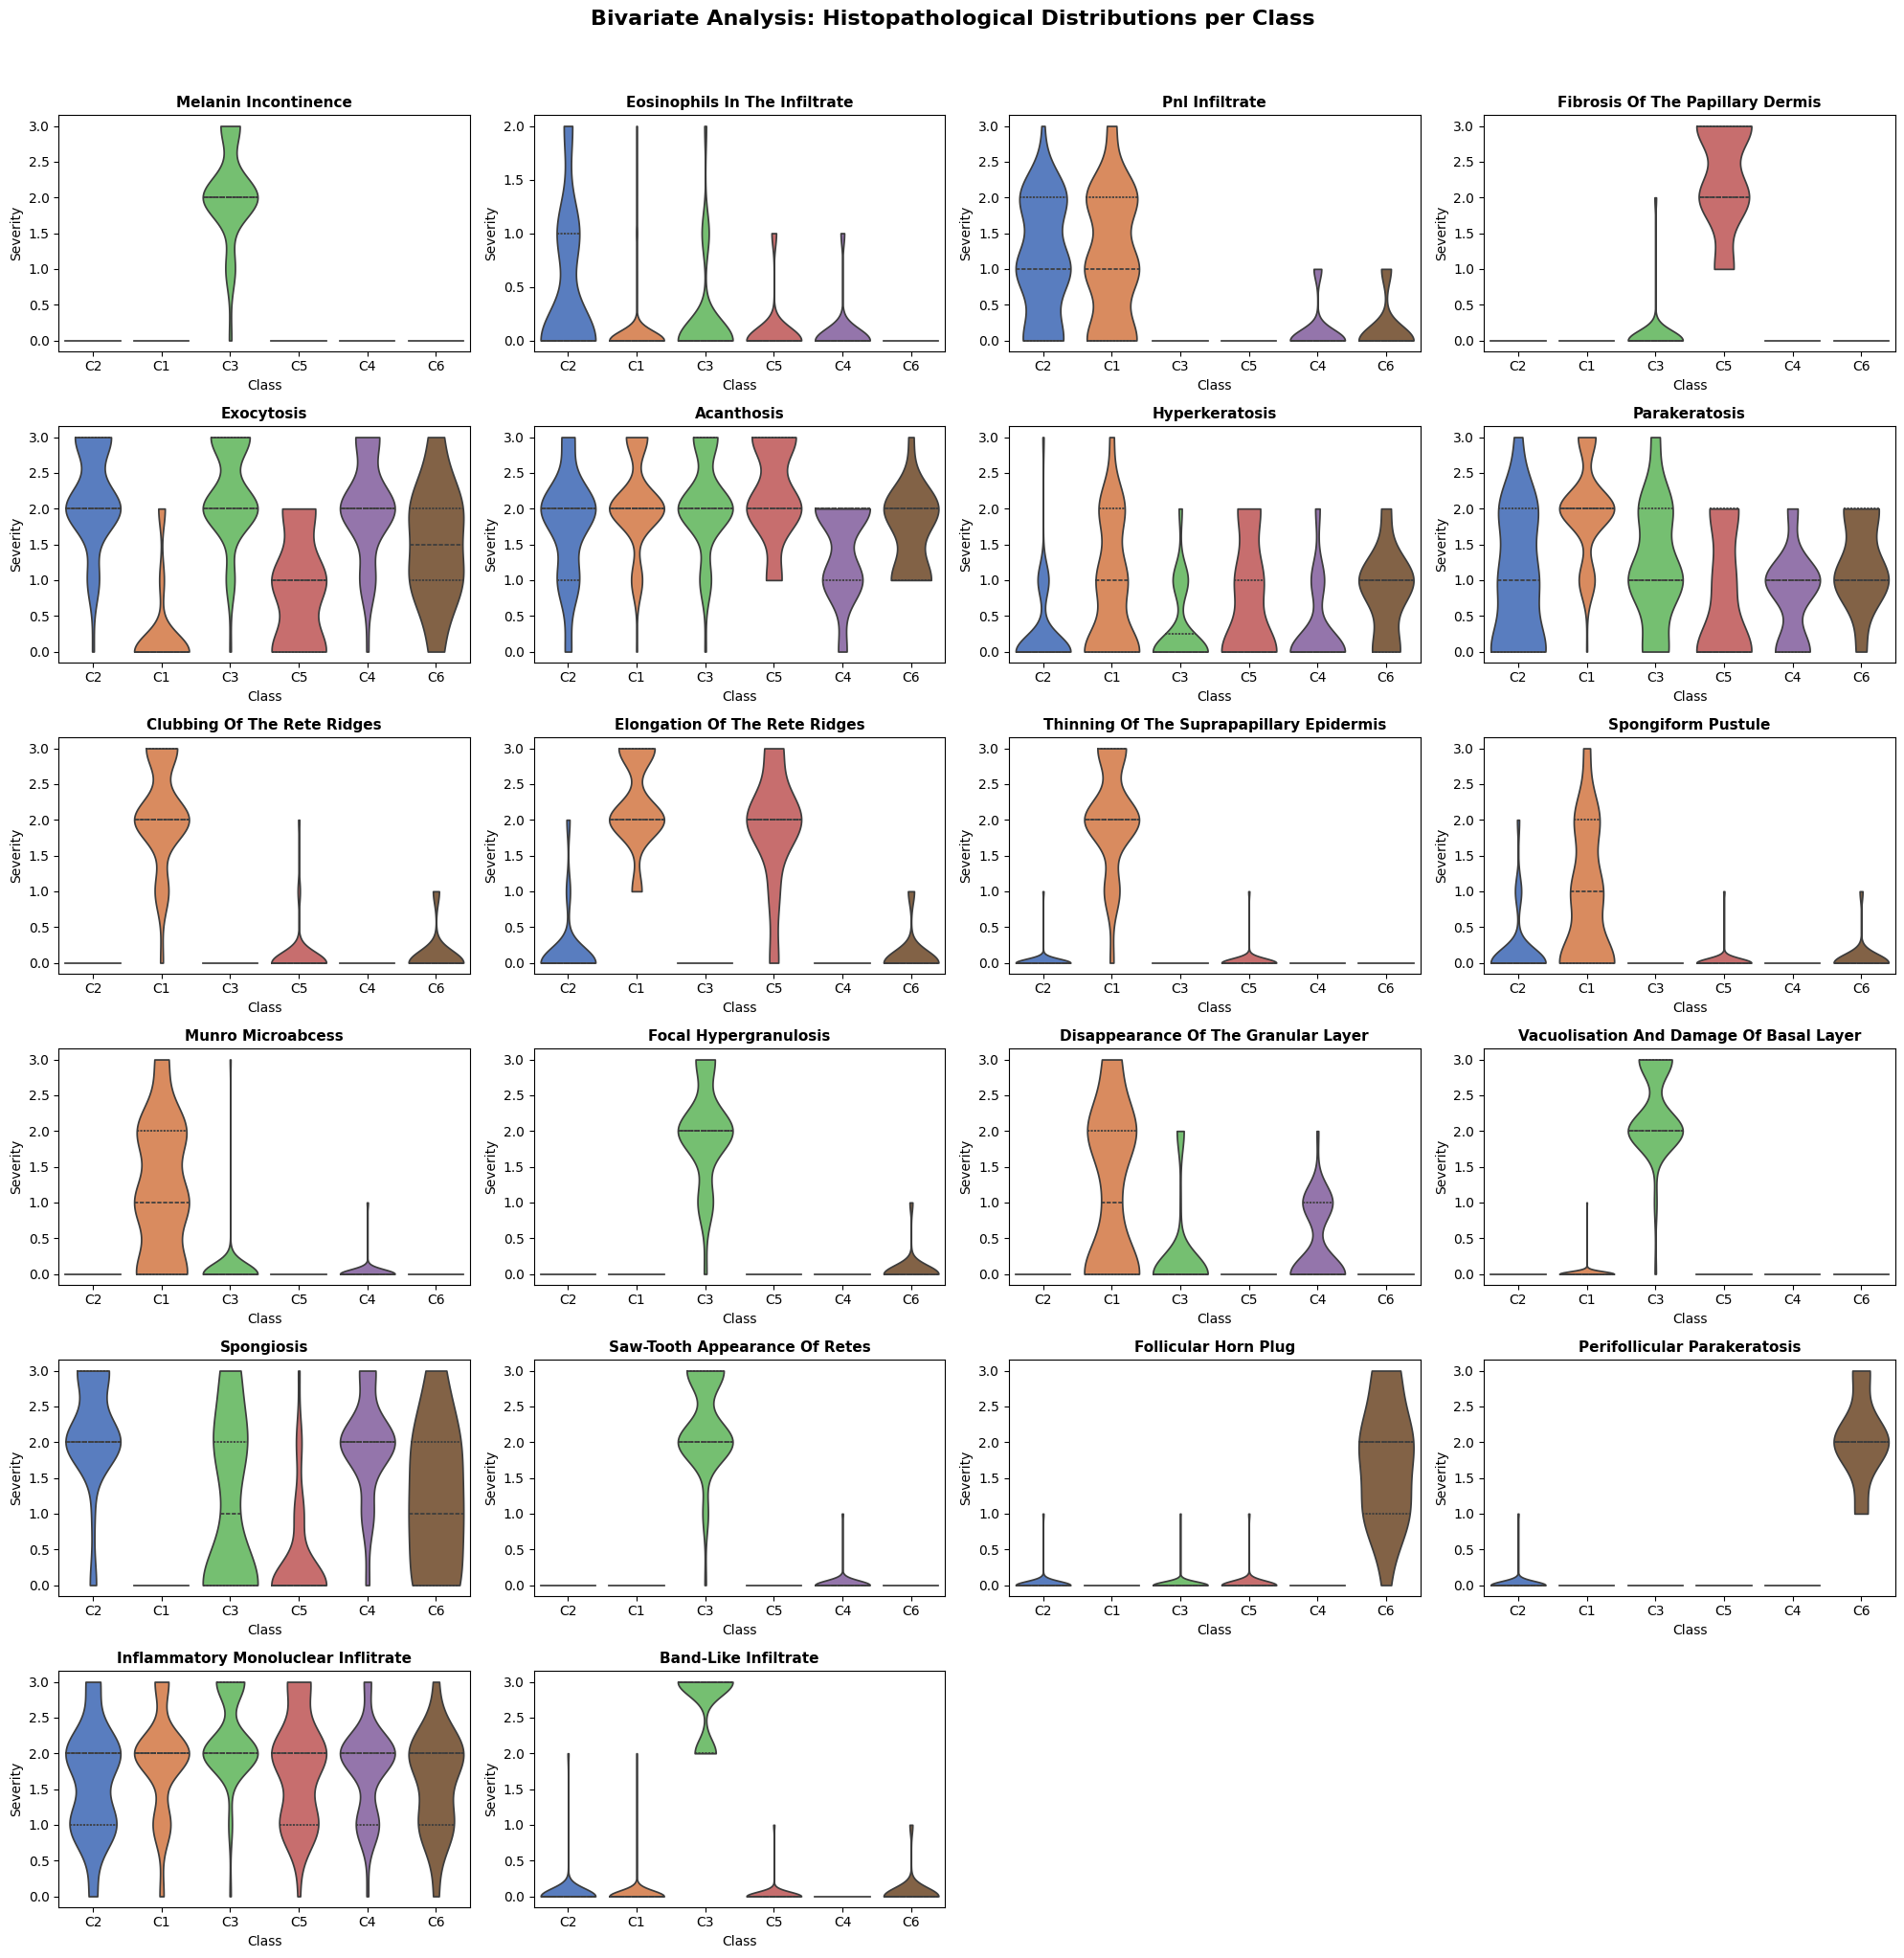

In [ ]:
# HISTOPATHOLOGICAL FEATURES vs DISEASE CLASS
# Selecting key microscopic features (starting from column 12 onwards)
histo_features = data.columns[11:33]

temp_histo = data.copy()
temp_histo['Disease'] = temp_histo['class'].map(lambda x: f"C{x}")

# 2 rows x 4 columns grid
fig, axes = plt.subplots(6, 4, figsize=(20, 20))
axes = axes.flatten()

for i, feat in enumerate(histo_features):
    sns.violinplot(data=temp_histo, x='Disease', y=feat,
                   palette='muted', ax=axes[i], inner='quartile', cut=0)

    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Severity')
for j in range(len(histo_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Bivariate Analysis: Histopathological Distributions per Class',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*Insights*
* Specific Microscopic Markers: Saw-tooth appearance of retes and Fibrosis of the papillary dermis are highly specific "one-class" markers, appearing almost exclusively in Class 3 and Class 5, respectively.

* Structural Changes: Features like Clubbing and Elongation of the rete ridges are signature microscopic signs of Class 1 `(Psoriasis)`.

* Class Distinction: These histopathological features provide much "sharper" data than clinical symptoms, which helps the model achieve high accuracy (95%+) by reducing class overlap.

***3) Multivariate***

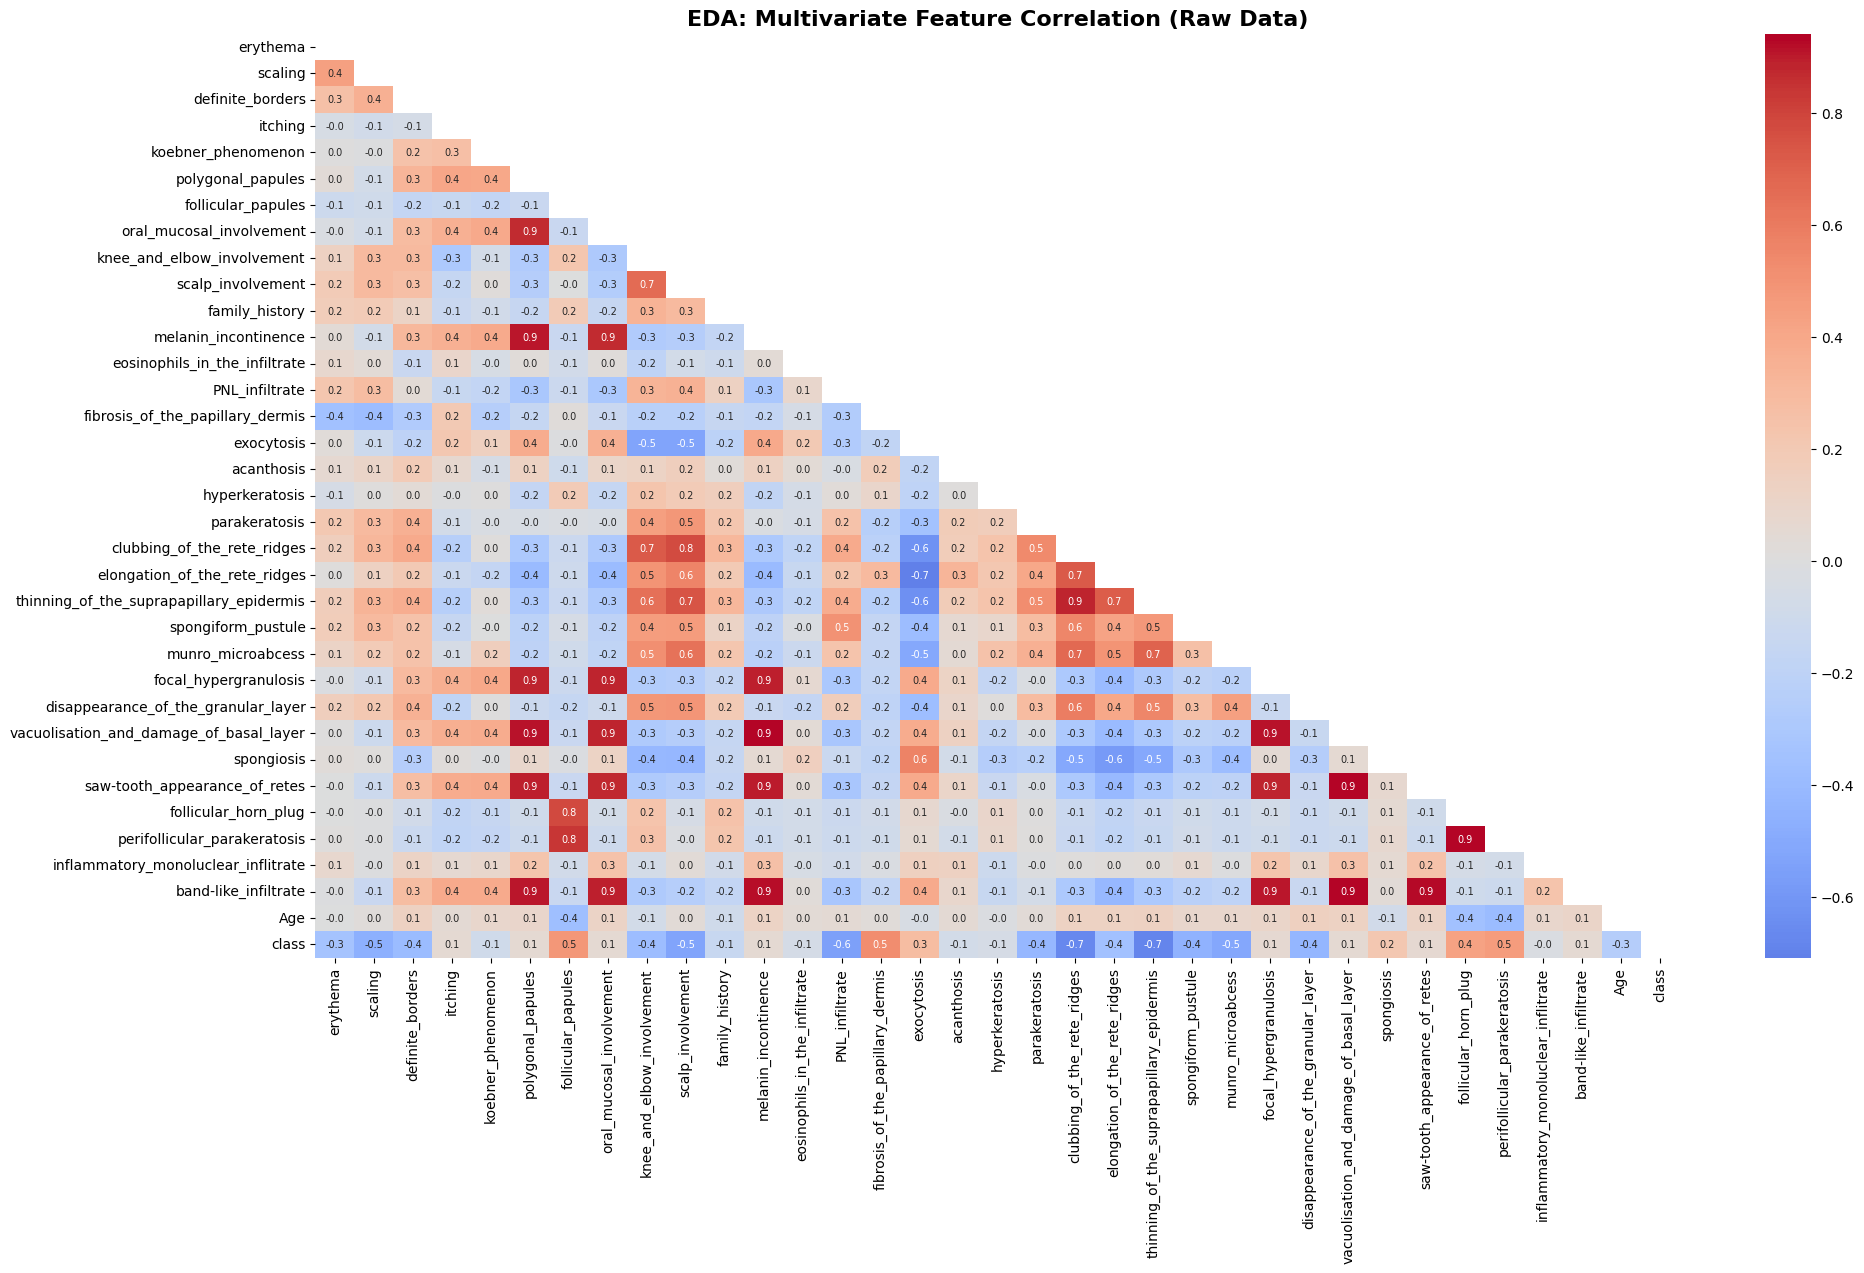

Top 5 Features Correlated with Target (Disease Class):
thinning_of_the_suprapapillary_epidermis    0.684864
clubbing_of_the_rete_ridges                 0.668781
PNL_infiltrate                              0.550195
scalp_involvement                           0.533208
fibrosis_of_the_papillary_dermis            0.526976
Name: class, dtype: float64


In [ ]:
# MULTIVARIATE: INITIAL CORRELATION HEATMAP (EDA)

plt.figure(figsize=(22, 12))

# We calculate correlation on the raw data (Age nulls are ignored automatically by .corr())
corr_matrix = data.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.1f',
            cmap='coolwarm', center=0, annot_kws={"size": 7})

plt.title('EDA: Multivariate Feature Correlation (Raw Data)', fontsize=16, fontweight='bold')
plt.show()

# AI Engineering Check: Identify top correlations with the target
target_corr = corr_matrix['class'].abs().sort_values(ascending=False)
print("Top 5 Features Correlated with Target (Disease Class):")
print(target_corr.iloc[1:6]) # iloc[1:6] to skip 'class' vs 'class'

*Insights*
* Target Correlation: "Features like `thinning_of_the_suprapapillary_epidermis` show the highest correlation with the target class, indicating they are primary drivers for the model's predictions."

* Multicollinearity Warning: "We observe several feature pairs (e.g., `specific microscopic` markers) with correlation coefficients above 0.8. We will re-verify these after data cleaning to decide on feature dropping."

---
## ***Data Preprocessing***

***1) HANDLING MISSING VALUES***

In [ ]:

missing_before = data['Age'].isna().sum()
age_median = data['Age'].median()

print(f"Missing Age values before imputation : {missing_before}")
print(f"Median Age used for filling          : {age_median:.0f} years")

# Fill the 8 missing values in the Age column
data['Age'] = data['Age'].fillna(age_median)


print(f"Successfully imputed missing Age values with Median: {age_median}")
print(f"Remaining Nulls in Age: {data['Age'].isnull().sum()}")

Missing Age values before imputation : 8
Median Age used for filling          : 35 years
Successfully imputed missing Age values with Median: 35.0
Remaining Nulls in Age: 0


***2) Outlier Detection***

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define Upper and Lower Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data['Age'] < lower_bound) | (data['Age'] > upper_bound)]

print(f"Age Statistics: Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers detected in Age: {len(outliers)}")

Age Statistics: Q1=25.0, Q3=48.0, IQR=23.0
Lower Bound: -9.5, Upper Bound: 82.5
Number of Outliers detected in Age: 0


* *There are no outliers in the Age Column*
* *So no need to handle it*

***3) Multicollinearity Check — Drop Redundant Features***

In [ ]:
# 1. Identify pairs with correlation > 0.85
corr_matrix = data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 2. Find features to drop
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print(f"Redundant features identified for removal: \n{to_drop}")

# 3. Drop the features from the dataset
data = data.drop(columns=to_drop)

print(f"Final dataset shape after Feature Selection: {data.shape}")

Redundant features identified for removal: 
['oral_mucosal_involvement', 'melanin_incontinence', 'thinning_of_the_suprapapillary_epidermis', 'focal_hypergranulosis', 'vacuolisation_and_damage_of_basal_layer', 'saw-tooth_appearance_of_retes', 'perifollicular_parakeratosis', 'band-like_infiltrate']
Final dataset shape after Feature Selection: (366, 27)


***4) Heatmap After Handling multi-colinearity***

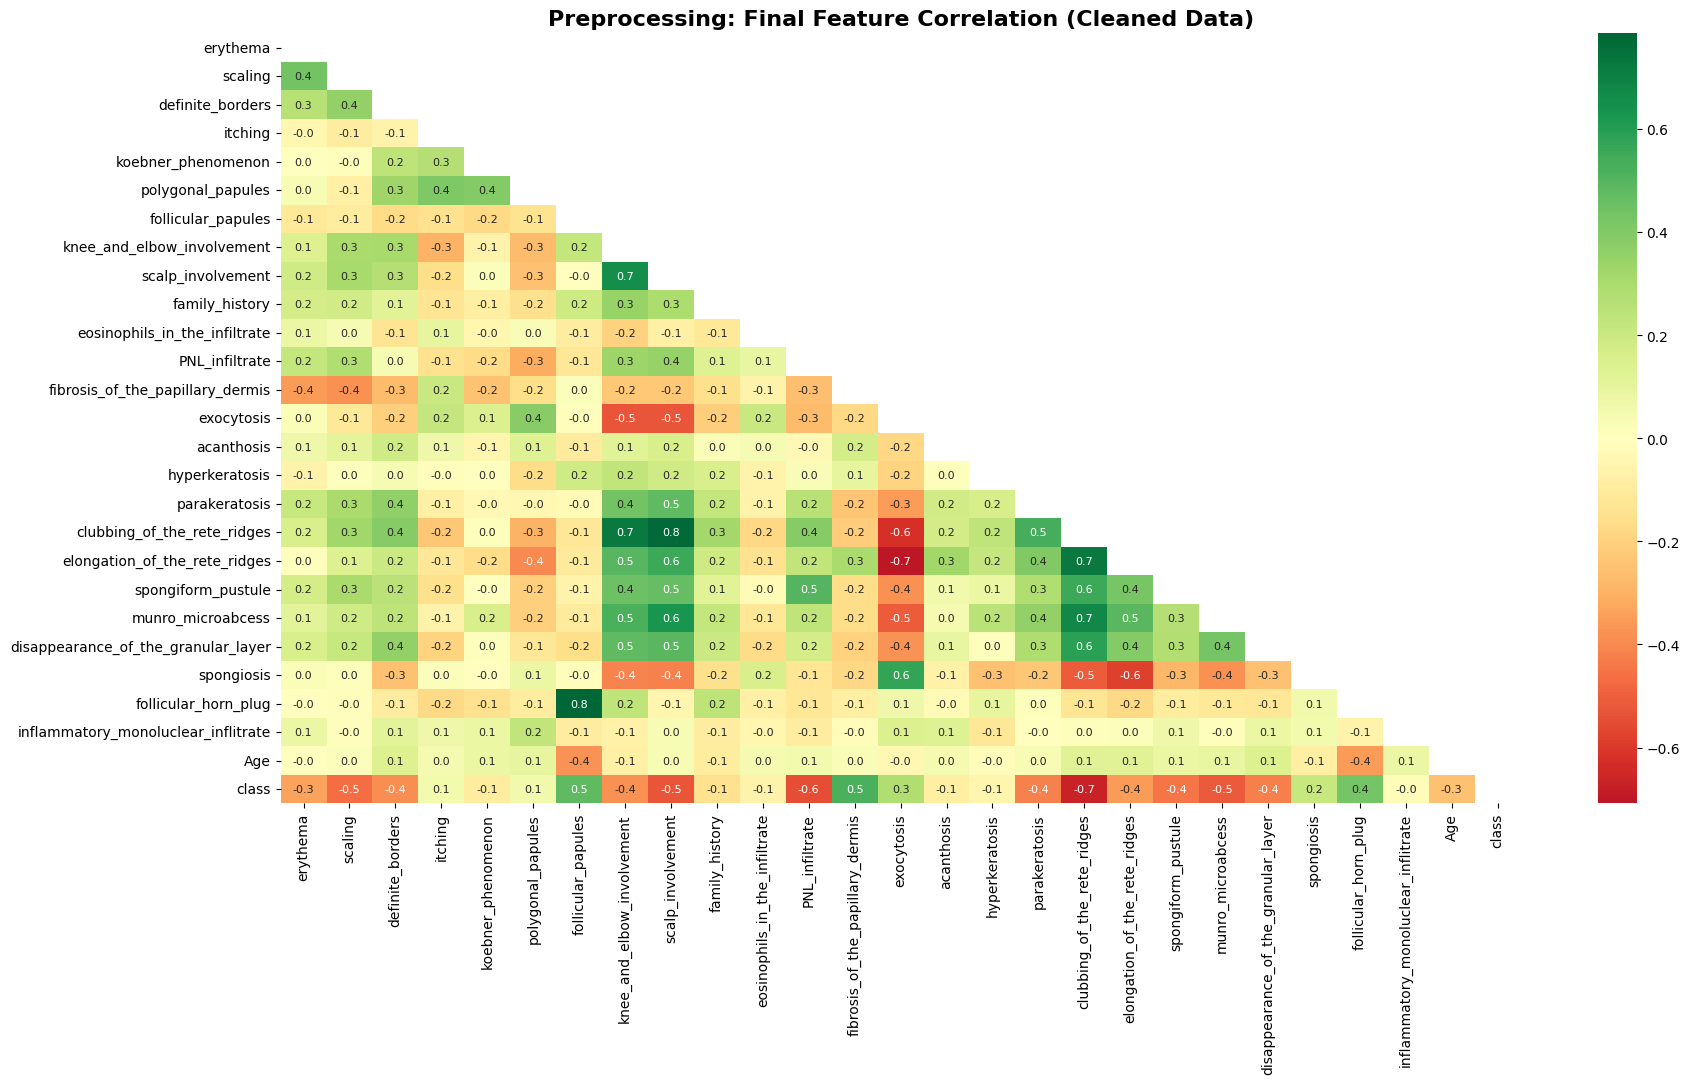

Final Feature Count: 27
Multicollinearity has been resolved. Data is ready for Model Building.


In [ ]:
plt.figure(figsize=(20, 10))

# Calculating correlation on the cleaned 'data' variable
final_corr = data.corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(final_corr, dtype=bool))

sns.heatmap(final_corr, mask=mask, annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, annot_kws={"size": 8})

plt.title('Preprocessing: Final Feature Correlation (Cleaned Data)', fontsize=16, fontweight='bold')
plt.show()

print(f"Final Feature Count: {data.shape[1]}")
print("Multicollinearity has been resolved. Data is ready for Model Building.")

***5) Stratified Train-Test Split***

In [ ]:
# Define Features (X) and Target (y)
X = data.drop('class', axis=1)
y = data['class']

# Splitting the data (80% Train, 20% Test)
# stratify=y is CRITICAL for imbalanced medical data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print(y_test.value_counts().sort_index())

Training Samples: 292
Test Samples: 74
class
1    23
2    12
3    15
4    10
5    10
6     4
Name: count, dtype: int64


***6) Feature Scalling***

In [ ]:
# Our features are on 0-3 scale EXCEPT Age (0-80+)
# Without scaling: Age (range 80) dominates features with range 3
# StandardScaler transforms each feature to: mean=0, std=1

# We fit on train and transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been scaled using StandardScaler.")
print(f"Age (unscaled) mean: {X_train['Age'].mean():.2f}")
print(f"Age (scaled) mean: {X_train_scaled[:, X_train.columns.get_loc('Age')].mean():.2f}")

Data has been scaled using StandardScaler.
Age (unscaled) mean: 36.67
Age (scaled) mean: -0.00


---
## ***Model Building & Performance Evaluation***

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # As Analyzed before that for Class 6 there is more imbalancing so for that we need
                                                                  # to train model on balanced data, Hence Initializing Stratified K Fold

***BaseLine Model --- Logistic Rgression***

--- Logistic Regression: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.83      1.00      0.91        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.98      0.97      0.97        74

Test Accuracy : 0.9730
CV Accuracy   : 0.9623 ± 0.0169


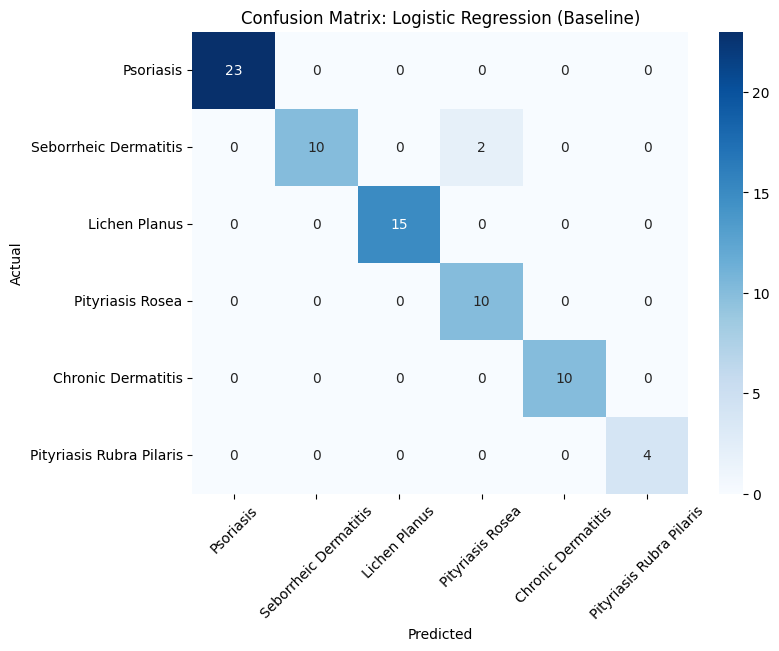

In [ ]:
# 1. Initialize and Train
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Dual Accuracy Evaluation
test_acc_lr = accuracy_score(y_test, y_pred_lr)
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report
print("--- Logistic Regression: Detailed Classification Report ---")

print(classification_report(y_test, y_pred_lr, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_lr:.4f}")
print(f"CV Accuracy   : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap='Blues', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: Logistic Regression (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

***Model 2 --- K-Nearest Neighbour(KNN)***

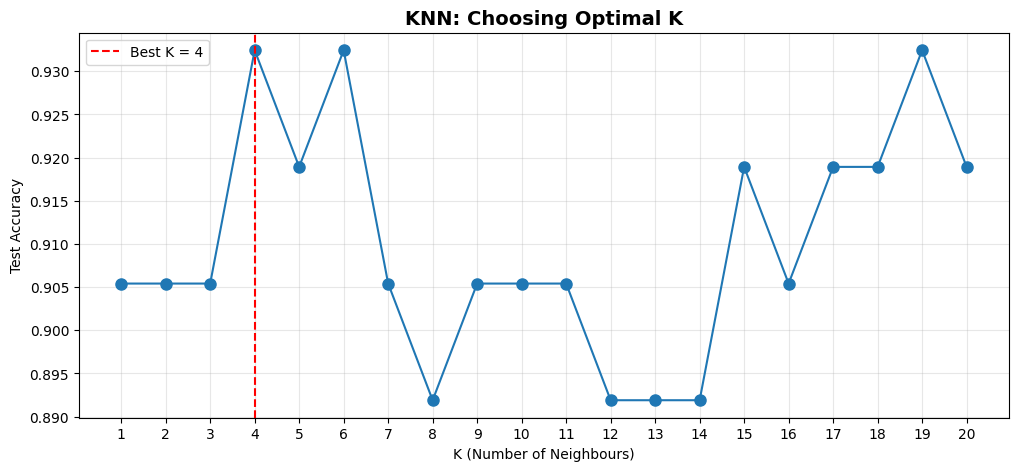

KNN trained with optimal K = 4 (Accuracy: 93.24%)


In [ ]:
accuracy_scores = []

# Testing K values from 1 to 20
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    accuracy_scores.append(score)

# Identify the best K (highest accuracy)
best_k = accuracy_scores.index(max(accuracy_scores)) + 1
max_acc = max(accuracy_scores)

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(range(1, 21), accuracy_scores, marker='o', linestyle='-', markersize=8)

# Add the red vertical line for the best K
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('KNN: Choosing Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Test Accuracy')
plt.xticks(range(1, 21))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"KNN trained with optimal K = {best_k} (Accuracy: {max_acc:.2%})")

--- KNN (K=4): Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
   Seborrheic Dermatitis       0.82      0.75      0.78        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.75      0.90      0.82        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.93        74
               macro avg       0.93      0.93      0.93        74
            weighted avg       0.94      0.93      0.93        74

Test Accuracy : 0.9324
CV Accuracy   : 0.9658 ± 0.0185


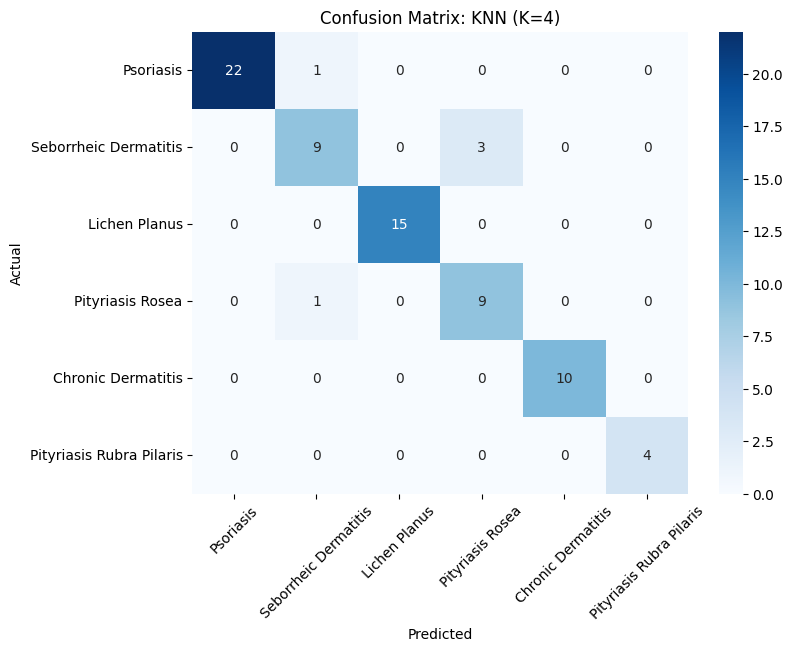

In [ ]:
# 1. Initialize and Train with the Best K found previously
# We use the 'best_k' variable from your earlier optimization loop
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_knn = knn_final.predict(X_test_scaled)

# 3. Dual Accuracy Evaluation
test_acc_knn = accuracy_score(y_test, y_pred_knn)
cv_scores_knn = cross_val_score(knn_final, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report
print(f"--- KNN (K={best_k}): Detailed Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_knn:.4f}")
print(f"CV Accuracy   : {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Blues', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title(f'Confusion Matrix: KNN (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

***Model 3 --- Decision Tree***

--- Decision Tree (Gini): Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      0.96      0.98        23
   Seborrheic Dermatitis       0.83      0.83      0.83        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.91      1.00      0.95        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       0.75      0.75      0.75         4

                accuracy                           0.95        74
               macro avg       0.92      0.92      0.92        74
            weighted avg       0.95      0.95      0.95        74

Test Accuracy : 0.9459
CV Accuracy   : 0.9383 ± 0.0085


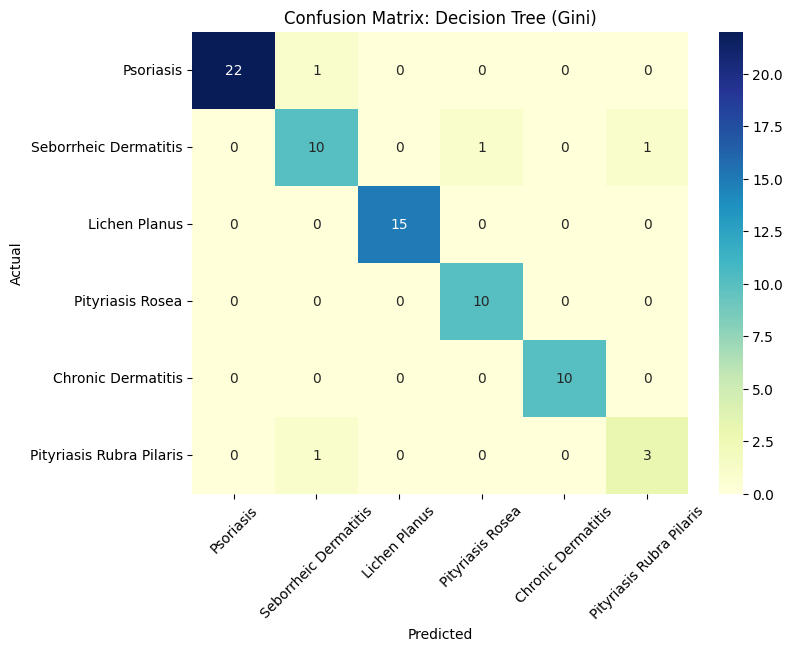

In [ ]:
# 1. Initialize and Train
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# 3. Dual Accuracy Evaluation
test_acc_dt = accuracy_score(y_test, y_pred_dt)
cv_scores_dt = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report
print("--- Decision Tree (Gini): Detailed Classification Report ---")
print(classification_report(y_test, y_pred_dt, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_dt:.4f}")
print(f"CV Accuracy   : {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, cmap='YlGnBu', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: Decision Tree (Gini)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

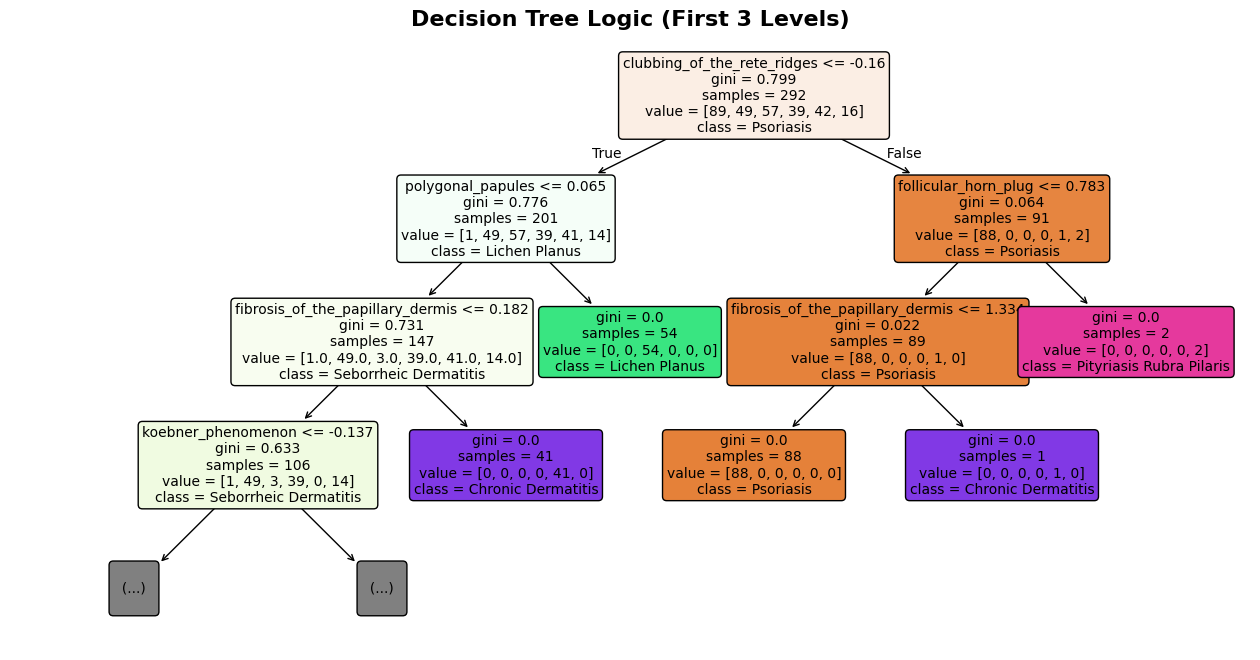

In [ ]:
# 6. Visualizing the Logic (Top 3 Levels)
plt.figure(figsize=(16, 8))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=[disease_map[i] for i in range(1,7)],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Decision Tree Logic (First 3 Levels)", fontsize=16, fontweight='bold')
plt.show()

***Model 4 --- Random Forest***

--- Random Forest: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.92      0.92      0.92        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.90      0.90      0.90        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.97      0.97      0.97        74

Test Accuracy : 0.9730
CV Accuracy   : 0.9692 ± 0.0068


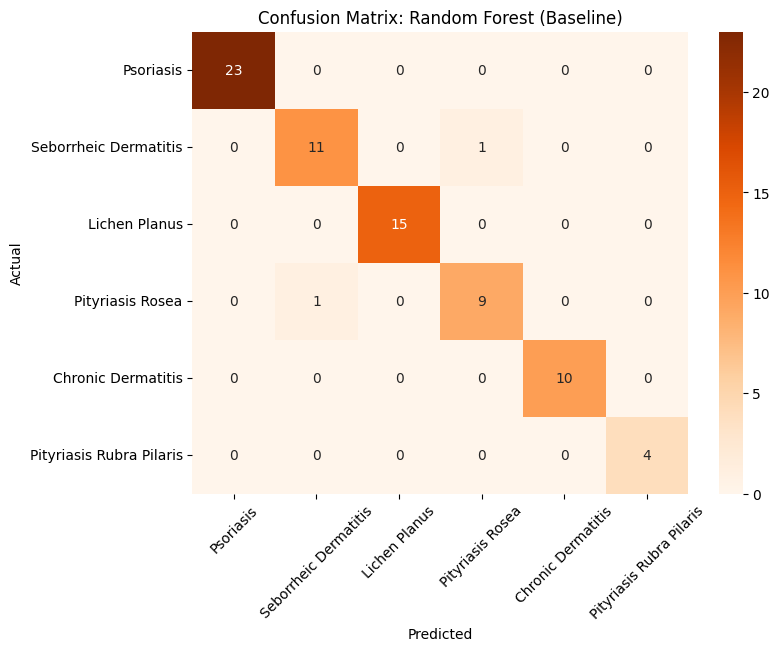

In [ ]:
# 1. Initialize and Train Baseline Model
# We use 100 trees as a standard default
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight = 'balanced')
rf_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Accuracy Evaluation
test_acc_rf = accuracy_score(y_test, y_pred_rf)
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report
print("--- Random Forest: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_rf:.4f}")
print(f"CV Accuracy   : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Oranges', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: Random Forest (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

In [ ]:
clinical_list = ['erythema', 'scaling', 'definite_borders', 'itching',
                 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
                 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'Age']

clinical_list = [f for f in clinical_list if f in X.columns]

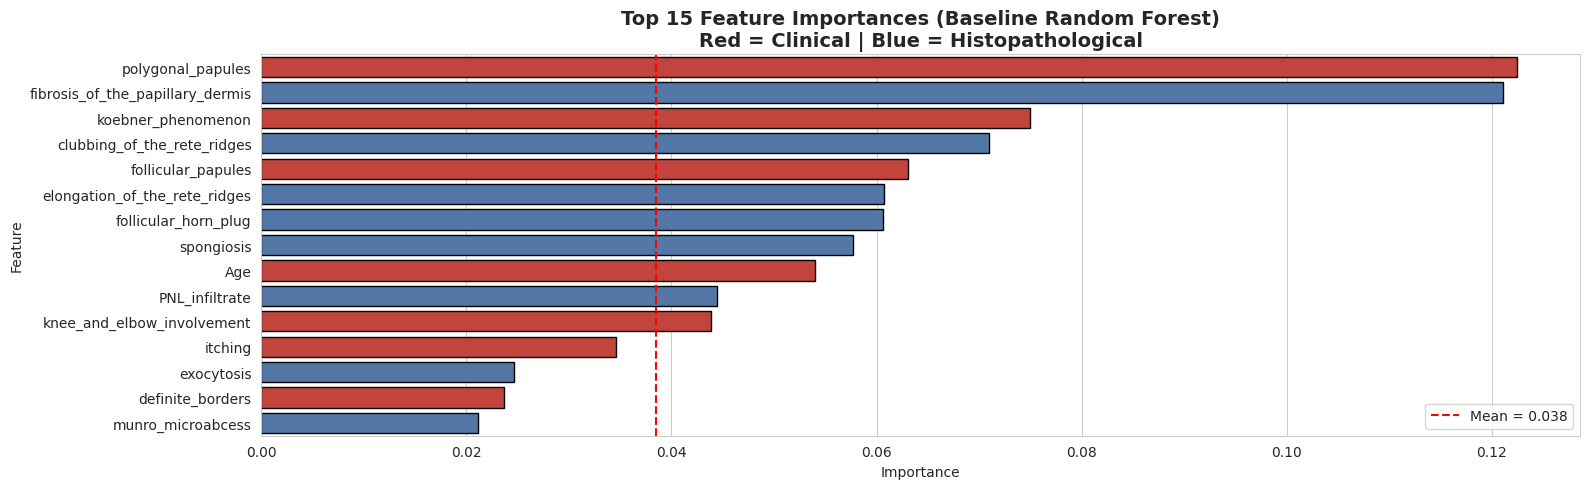

In [ ]:
# Get importances and sort
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top_15 = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Assign colors based on category: Red = Clinical | Blue = Histopathological[cite: 1]
colors = ['#d73027' if feat in clinical_list else '#4575b4' for feat in top_15['Feature']]

# Plotting
plt.figure(figsize=(16, 5))
sns.barplot(x='Importance', y='Feature', data=top_15, palette=colors, edgecolor='black')

# Add mean importance line
mean_imp = importances.mean()
plt.axvline(mean_imp, color='red', linestyle='--', label=f'Mean = {mean_imp:.3f}')

plt.title('Top 15 Feature Importances (Baseline Random Forest)\nRed = Clinical | Blue = Histopathological', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

***Model 5 --- Support Vector Machine(SVM)***

--- SVM: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       0.96      1.00      0.98        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      0.93      0.97        15
        Pityriasis Rosea       0.83      1.00      0.91        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.97      0.96      0.96        74
            weighted avg       0.96      0.96      0.96        74

Test Accuracy : 0.9595
CV Accuracy   : 0.9691 ± 0.0129


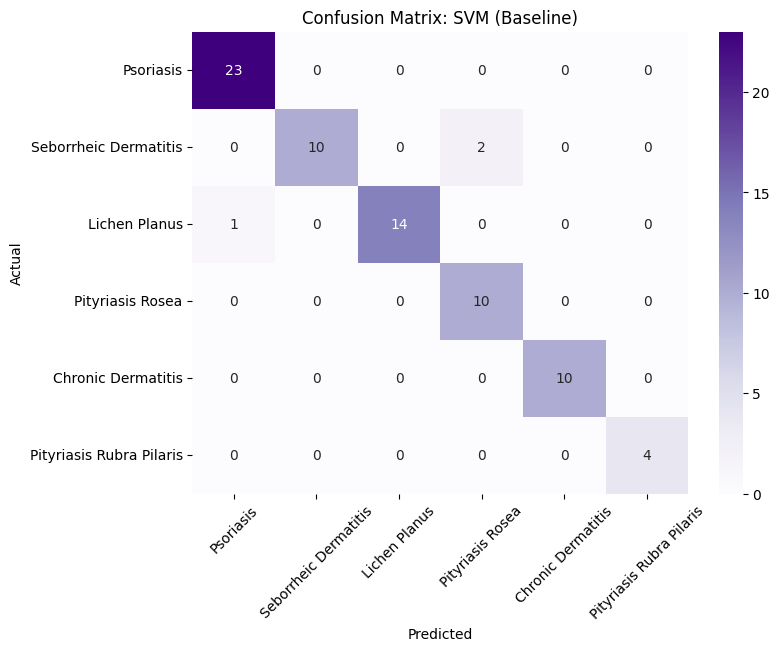

In [ ]:
# 1. Initialize and Train Baseline Model
# Using a linear kernel and probability=True for consistent evaluation
svm_model = SVC(
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42,
    class_weight = 'balanced'
    )
svm_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# 3. Accuracy Evaluation
test_acc_svm = accuracy_score(y_test, y_pred_svm)
cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report (The Table)
print("--- SVM: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_svm:.4f}")
print(f"CV Accuracy   : {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, cmap='Purples', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: SVM (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

***Model 6 --- XGBoost***

--- XGBoost: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.90      0.75      0.82        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.75      0.90      0.82        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.95        74
               macro avg       0.94      0.94      0.94        74
            weighted avg       0.95      0.95      0.95        74

Test Accuracy : 0.9459
CV Accuracy   : 0.9657 ± 0.0110


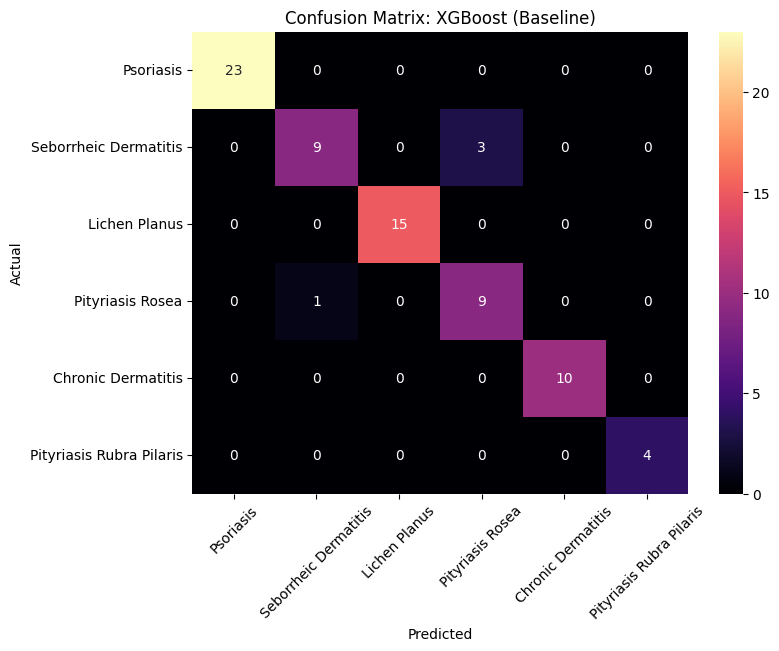

In [ ]:
# 1. Initialize and Train Baseline Model
# XGBoost requires class labels to start at 0, so we subtract 1 from your 1-6 labels
xgb_model = XGBClassifier(n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
    )
xgb_model.fit(X_train_scaled, y_train - 1)

# 2. Make Predictions
# We add 1 back to the predictions so they match your original 1-6 scale
y_pred_xgb = xgb_model.predict(X_test_scaled) + 1

# 3. Accuracy Evaluation
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train - 1, cv=skf)

# 4. Detailed Classification Report
print("--- XGBoost: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_xgb:.4f}")
print(f"CV Accuracy   : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, cmap='magma', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: XGBoost (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

***Model 7 --- Artificial Neural Network(ANN)***

--- ANN: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.91      0.83      0.87        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.75      0.90      0.82        10
      Chronic Dermatitis       1.00      0.90      0.95        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.95        74
               macro avg       0.94      0.94      0.94        74
            weighted avg       0.95      0.95      0.95        74

Test Accuracy : 0.9459
CV Accuracy   : 0.9044 ± 0.0539


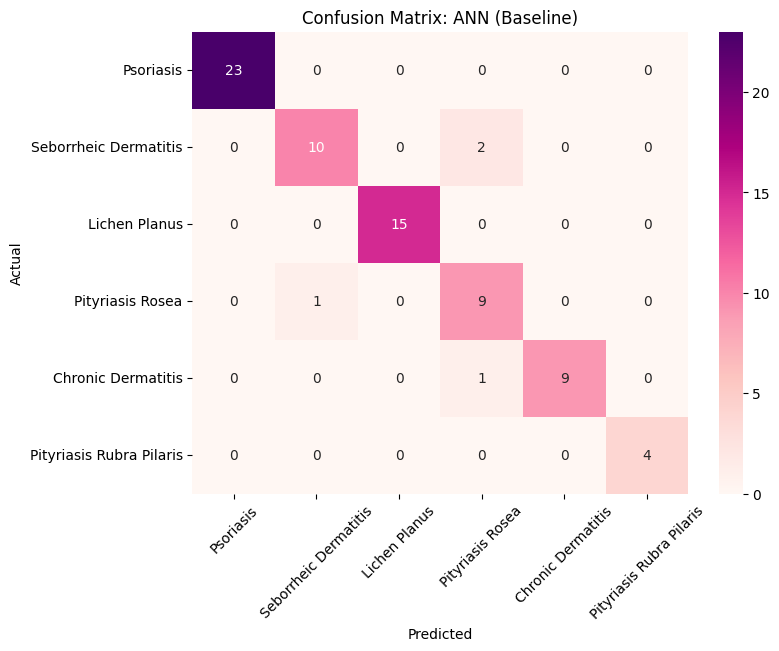

In [ ]:
# 1. Initialize and Train Baseline Model
# Using two hidden layers with 64 and 32 neurons respectively
ann_model = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=500,
              random_state=42, early_stopping=True, validation_fraction=0.1,
              n_iter_no_change=10, alpha=0.001)
ann_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_ann = ann_model.predict(X_test_scaled)

# 3. Accuracy Evaluation
test_acc_ann = accuracy_score(y_test, y_pred_ann)
cv_scores_ann = cross_val_score(ann_model, X_train_scaled, y_train, cv=skf)

# 4. Detailed Classification Report (The Table)
print("--- ANN: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_ann, target_names=list(disease_map.values())))

print(f"Test Accuracy : {test_acc_ann:.4f}")
print(f"CV Accuracy   : {cv_scores_ann.mean():.4f} ± {cv_scores_ann.std():.4f}")

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, cmap='RdPu', fmt='d',
            xticklabels=list(disease_map.values()), yticklabels=list(disease_map.values()))
plt.title('Confusion Matrix: ANN (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

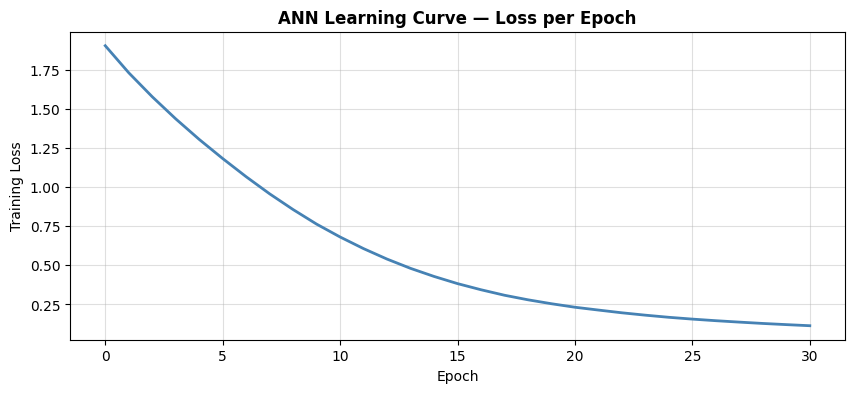

Training started at loss: 1.9054
Training ended at loss:   0.1135


In [ ]:
# ANN Learning Curve
plt.figure(figsize=(10, 4))
plt.plot(ann_model.loss_curve_, color='steelblue', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('ANN Learning Curve — Loss per Epoch', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.show()
print(f"Training started at loss: {ann_model.loss_curve_[0]:.4f}")
print(f"Training ended at loss:   {ann_model.loss_curve_[-1]:.4f}")

# ***Hyper Parameter Tuning***

***Model 4 --- Random Forest***

In [ ]:
# Define the grid of parameters to test
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the search
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42,class_weight = 'balanced'),
    param_grid_rf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

# Identify the best model
best_rf = grid_rf.best_estimator_

print(f"Best Parameters: {grid_rf.best_params_}")
cv_scores_best_rf = cross_val_score(best_rf, X_train_scaled, y_train, cv=skf)
print(f"CV Mean Accuracy : {cv_scores_best_rf.mean():.4f}")
print(f"CV Std Deviation : ± {cv_scores_best_rf.std():.4f}")


# Final Evaluation of the Tuned Model
y_pred_best_rf = best_rf.predict(X_test_scaled)
test_acc_best_rf = accuracy_score(y_test, y_pred_best_rf)


print(f"Test Accuracy : {test_acc_best_rf:.4f}")
print("\n--- Tuned Random Forest: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_best_rf, target_names=list(disease_map.values())))


Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
CV Mean Accuracy : 0.9760
CV Std Deviation : ± 0.0085
Test Accuracy : 0.9730

--- Tuned Random Forest: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.92      0.92      0.92        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.90      0.90      0.90        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.97      0.97      0.97        74



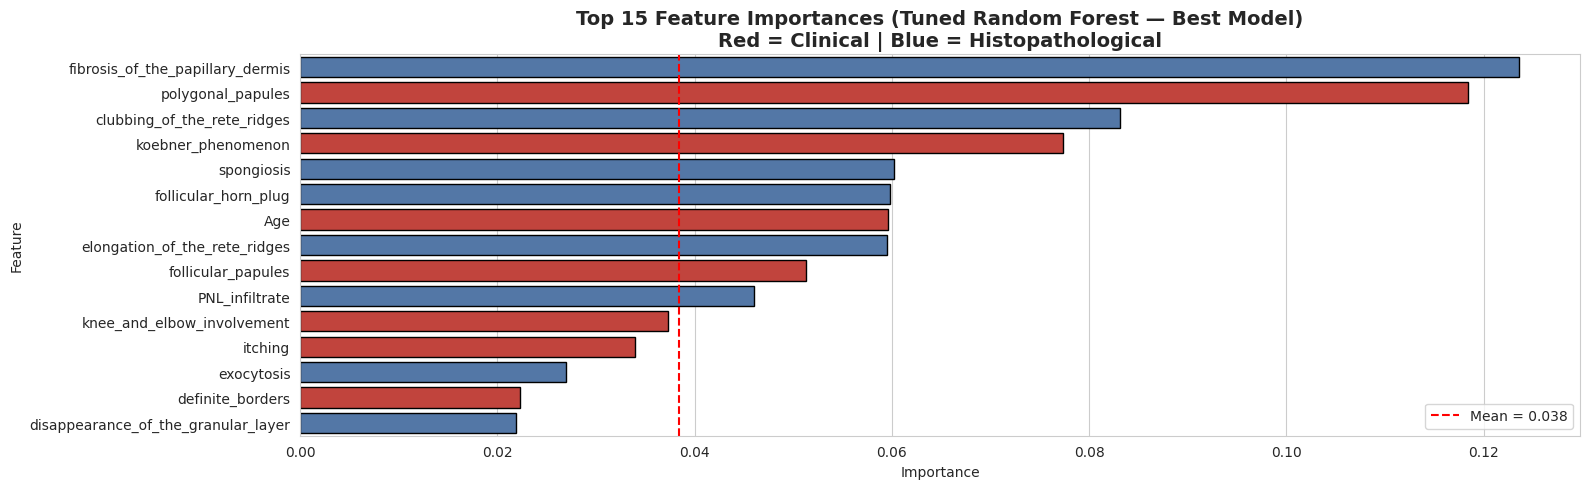

In [ ]:
# Feature Importances from the BEST (Tuned) Model
importances_tuned = best_rf.feature_importances_
feat_df_tuned = pd.DataFrame({'Feature': X.columns, 'Importance': importances_tuned})
top15_tuned = feat_df_tuned.sort_values('Importance', ascending=False).head(15)
colors_tuned = ['#d73027' if f in clinical_list else '#4575b4' for f in top15_tuned['Feature']]

plt.figure(figsize=(16, 5))
sns.barplot(x='Importance', y='Feature', data=top15_tuned, palette=colors_tuned, edgecolor='black')
plt.axvline(importances_tuned.mean(), color='red', linestyle='--', label=f"Mean = {importances_tuned.mean():.3f}")
plt.title('Top 15 Feature Importances (Tuned Random Forest — Best Model)\nRed = Clinical | Blue = Histopathological',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

***Model 5 --- SVM***

In [ ]:
# 1. Define the parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto',0.01,0.1]
}

# 2. Initialize and run GridSearchCV
grid_svm = GridSearchCV(SVC(probability=True, random_state=42,class_weight = 'balanced'),
                        param_grid_svm,
                        cv=skf,
                        scoring='accuracy',
                        n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# 3. Identify the best model
best_svm = grid_svm.best_estimator_

print(f"Best Parameters: {grid_svm.best_params_}")
cv_scores_best_svm = cross_val_score(best_svm, X_train_scaled, y_train, cv=skf)
print(f"CV Mean Accuracy : {cv_scores_best_svm.mean():.4f}")
print(f"CV Std Deviation : ± {cv_scores_best_svm.std():.4f}")


# 4. Final Evaluation of the Tuned Model
y_pred_best_svm = best_svm.predict(X_test_scaled)
test_acc_best_svm = accuracy_score(y_test,y_pred_best_svm )
print(f"Test Accuracy : {test_acc_best_svm:.4f}")
print("\n--- Tuned SVM: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_best_svm, target_names=list(disease_map.values())))



Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
CV Mean Accuracy : 0.9726
CV Std Deviation : ± 0.0138
Test Accuracy : 0.9730

--- Tuned SVM: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.83      1.00      0.91        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.98      0.97      0.97        74



***Model 6 --- XGBoost***

In [ ]:
# 1. Define the parameter grid
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# 2. Initialize and run GridSearchCV
# Reminder: We use y_train - 1 for XGBoost's 0-index requirement
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), param_grid_xgb, cv=skf, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train - 1)

# 3. Identify the best model
best_xgb = grid_xgb.best_estimator_

print(f"Best Parameters: {grid_xgb.best_params_}")
cv_scores_best_xgb = cross_val_score(best_xgb, X_train_scaled, y_train - 1, cv=skf)
print(f"CV Mean Accuracy : {cv_scores_best_xgb.mean():.4f}")
print(f"CV Std Deviation : ± {cv_scores_best_xgb.std():.4f}")


# 4. Final Evaluation of the Tuned Model
# We add 1 back to the predictions to match your disease_map (1-6)
y_pred_best_xgb = best_xgb.predict(X_test_scaled) + 1
test_acc_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"Test Accuracy : {test_acc_best_xgb:.4f}")
print("\n--- Tuned XGBoost: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_best_xgb, target_names=list(disease_map.values())))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
CV Mean Accuracy : 0.9624
CV Std Deviation : ± 0.0198
Test Accuracy : 0.9595

--- Tuned XGBoost: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.91      0.83      0.87        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.82      0.90      0.86        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.95      0.96      0.95        74
            weighted avg       0.96      0.96      0.96        74



***Model 7 --- ANN***

In [ ]:
# 1. Define the parameter grid
# We test different layer combinations and activation functions
param_grid_ann = {
    'hidden_layer_sizes': [(64,), (64, 32), (100,), (50, 50),(128, 64)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}

# 2. Initialize and run GridSearchCV
# ANN can take a moment to train, so we use n_jobs=-1 for speed
grid_ann = GridSearchCV(MLPClassifier(max_iter=1000, random_state=42),
                        param_grid_ann, cv=skf, scoring='accuracy', n_jobs=-1)
grid_ann.fit(X_train_scaled, y_train)

# 3. Identify the best model
best_ann = grid_ann.best_estimator_

print(f"Best Parameters: {grid_ann.best_params_}")
cv_scores_best_ann = cross_val_score(best_ann, X_train_scaled, y_train, cv=skf)
print(f"CV Mean Accuracy : {cv_scores_best_ann.mean():.4f}")
print(f"CV Std Deviation : ± {cv_scores_best_ann.std():.4f}")


# 4. Final Evaluation of the Tuned Model
y_pred_best_ann = best_ann.predict(X_test_scaled)
test_acc_best_ann = accuracy_score(y_test,y_pred_best_ann)
print(f"Test Accuracy : {test_acc_best_ann:.4f}")
print("\n--- Tuned ANN: Detailed Classification Report ---")
print(classification_report(y_test, y_pred_best_ann, target_names=list(disease_map.values())))

Best Parameters: {'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'sgd'}
CV Mean Accuracy : 0.9692
CV Std Deviation : ± 0.0068
Test Accuracy : 0.9730

--- Tuned ANN: Detailed Classification Report ---
                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       0.92      0.92      0.92        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.90      0.90      0.90        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.97      0.97      0.97        74



#***Model Comparison***

**1) MASTER MODEL COMPARISON — ALL MODELS, ALL METRICS**

In [ ]:

all_models_full = {
    'LR (Baseline)'    : (lr_model,    y_pred_lr,       y_train,     False),
    'KNN (Baseline)'   : (knn_final,   y_pred_knn,      y_train,     False),
    'DT (Baseline)'    : (dt_model,    y_pred_dt,       y_train,     False),
    'RF (Baseline)'    : (rf_model,    y_pred_rf,       y_train,     False),
    'SVM (Baseline)'   : (svm_model,   y_pred_svm,      y_train,     False),
    'XGB (Baseline)'   : (xgb_model,   y_pred_xgb,      y_train - 1, True),
    'ANN (Baseline)'   : (ann_model,   y_pred_ann,      y_train,     False),
    'RF (Tuned)'       : (best_rf,     y_pred_best_rf,  y_train,     False),
    'SVM (Tuned)'      : (best_svm,    y_pred_best_svm, y_train,     False),
    'XGB (Tuned)'      : (best_xgb,    y_pred_best_xgb, y_train - 1, True),
    'ANN (Tuned)'      : (best_ann,    y_pred_best_ann, y_train,     False),
}

rows = []

for name, (model, y_pred, y_cv, is_xgb) in all_models_full.items():

    # Cross Validation
    cv = cross_val_score(model, X_train_scaled, y_cv, cv=skf, scoring='accuracy')

    # Test Metrics
    test_acc  = accuracy_score(y_test, y_pred)
    macro_f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    macro_p   = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_r   = recall_score(y_test, y_pred, average='macro', zero_division=0)
    roc_auc   = roc_auc_score(
                    y_test,
                    model.predict_proba(X_test_scaled),
                    multi_class='ovr',
                    average='macro'
                )

    rows.append({
        'Model'          : name,
        'Test Acc'       : round(test_acc, 4),
        'CV Mean'        : round(cv.mean(), 4),
        'CV Std'         : round(cv.std(), 4),
        'Precision'      : round(macro_p, 4),
        'Recall'         : round(macro_r, 4),
        'F1 (Macro)'     : round(macro_f1, 4),
        'ROC-AUC'        : round(roc_auc, 4),
    })

master_df = pd.DataFrame(rows)

# Sort by CV Mean first (most reliable), then Test Acc
master_df = master_df.sort_values(
    by=['CV Mean', 'Test Acc', 'F1 (Macro)'],
    ascending=False
).reset_index(drop=True)

# Rank column
master_df.insert(0, 'Rank', range(1, len(master_df) + 1))

print("=" * 95)
print("           COMPLETE MODEL COMPARISON - ALL 11 MODELS, ALL METRICS")
print("=" * 95)
display(master_df)
print("=" * 95)
print(f"\n🏆 Best Model: {master_df.iloc[0]['Model']}")
print(f"   → CV Mean  : {master_df.iloc[0]['CV Mean']}")
print(f"   → CV Std   : {master_df.iloc[0]['CV Std']}")
print(f"   → Test Acc : {master_df.iloc[0]['Test Acc']}")
print(f"   → F1 Macro : {master_df.iloc[0]['F1 (Macro)']}")

           COMPLETE MODEL COMPARISON - ALL 11 MODELS, ALL METRICS


,Rank,Model,Test Acc,CV Mean,CV Std,Precision,Recall,F1 (Macro),ROC-AUC
0,1,RF (Tuned),0.9730,0.9760,0.0085,0.9694,0.9694,0.9694,0.9979
1,2,SVM (Tuned),0.9730,0.9726,0.0138,0.9722,0.9722,0.9697,0.9973
2,3,RF (Baseline),0.9730,0.9692,0.0068,0.9694,0.9694,0.9694,0.9983
3,4,ANN (Tuned),0.9730,0.9692,0.0068,0.9694,0.9694,0.9694,0.9984
4,5,SVM (Baseline),0.9595,0.9691,0.0129,0.9653,0.9611,0.9604,0.9976
5,6,KNN (Baseline),0.9324,0.9658,0.0185,0.9280,0.9344,0.9298,0.9871
6,7,XGB (Baseline),0.9459,0.9657,0.0110,0.9417,0.9417,0.9394,0.9950
7,8,XGB (Tuned),0.9595,0.9624,0.0198,0.9545,0.9556,0.9545,0.9950
8,9,LR (Baseline),0.9730,0.9623,0.0169,0.9722,0.9722,0.9697,0.9981
9,10,DT (Baseline),0.9459,0.9383,0.0085,0.9154,0.9233,0.9189,0.9565



🏆 Best Model: RF (Tuned)
   → CV Mean  : 0.976
   → CV Std   : 0.0085
   → Test Acc : 0.973
   → F1 Macro : 0.9694


**2) TIE BREAKER CHART — WHY RF TUNED WINS THE TIE**

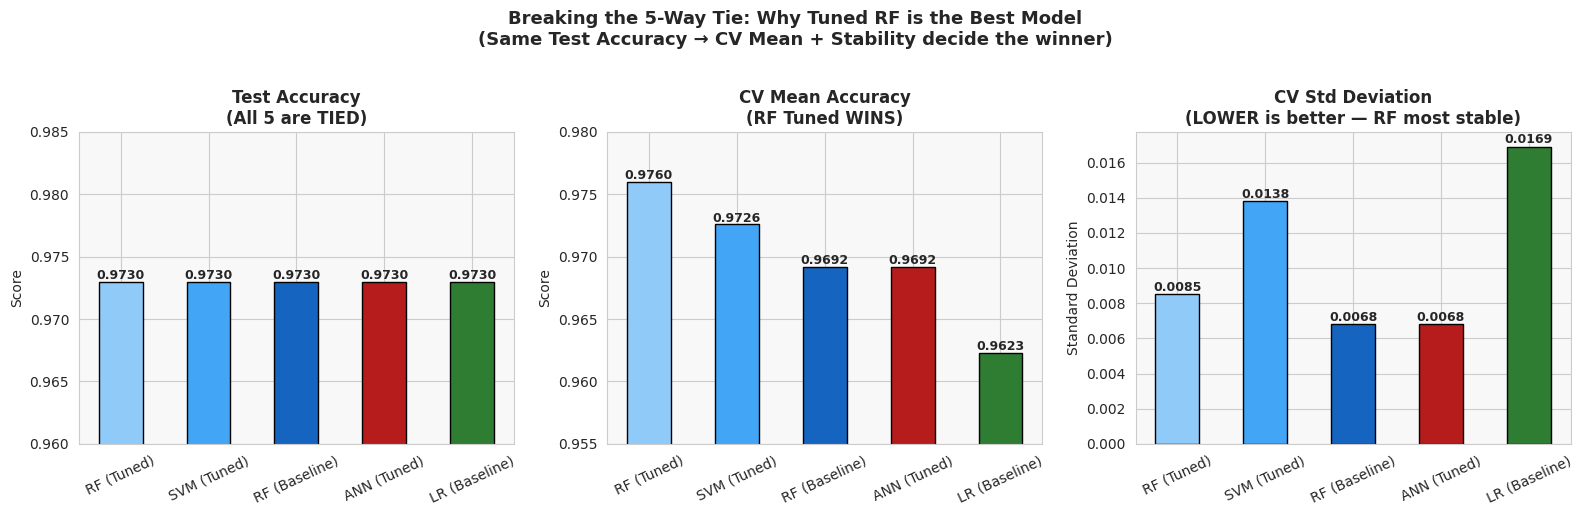


Reading guide:
   Chart 1: All 4 bars are identical → test accuracy cannot decide
   Chart 2: RF Tuned bar is TALLEST → highest CV Mean = most accurate on unseen data
   Chart 3: RF Tuned bar is SMALL(Stable) → low std = most consistent/reliable

Conclusion: RF (Tuned) wins on BOTH CV Mean AND stability → clear best model


In [ ]:


# Filter only the 4 tied models
tied_models = ['LR (Baseline)', 'RF (Baseline)', 'RF (Tuned)', 'SVM (Tuned)', 'ANN (Tuned)']
tied_df = master_df[master_df['Model'].isin(tied_models)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#90CAF9', '#42A5F5', '#1565C0', '#B71C1C','#2E7D32']
# Light blue = LR | Medium blue = RF Base | Dark blue = RF Tuned | Red = SVM Tuned

# --- Chart 1: Test Accuracy (shows the tie) ---
bars1 = axes[0].bar(tied_df['Model'], tied_df['Test Acc'],
                    color=colors, edgecolor='black', width=0.5)
axes[0].set_ylim(0.96, 0.985)
axes[0].set_title('Test Accuracy\n(All 5 are TIED)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars1, tied_df['Test Acc']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_facecolor('#f8f8f8')

# --- Chart 2: CV Mean (breaks the tie clearly) ---
bars2 = axes[1].bar(tied_df['Model'], tied_df['CV Mean'],
                    color=colors, edgecolor='black', width=0.5)
axes[1].set_ylim(0.955, 0.980)
axes[1].set_title('CV Mean Accuracy\n(RF Tuned WINS)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, tied_df['CV Mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_facecolor('#f8f8f8')

# --- Chart 3: CV Std (lower = more stable = better) ---
bars3 = axes[2].bar(tied_df['Model'], tied_df['CV Std'],
                    color=colors, edgecolor='black', width=0.5)
axes[2].set_title('CV Std Deviation\n(LOWER is better — RF most stable)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Standard Deviation')
axes[2].tick_params(axis='x', rotation=25)
for bar, val in zip(bars3, tied_df['CV Std']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_facecolor('#f8f8f8')

plt.suptitle('Breaking the 5-Way Tie: Why Tuned RF is the Best Model\n'
             '(Same Test Accuracy → CV Mean + Stability decide the winner)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tie_breaker.png', bbox_inches='tight')
plt.show()

print("\nReading guide:")
print("   Chart 1: All 4 bars are identical → test accuracy cannot decide")
print("   Chart 2: RF Tuned bar is TALLEST → highest CV Mean = most accurate on unseen data")
print("   Chart 3: RF Tuned bar is SMALL(Stable) → low std = most consistent/reliable")
print("\nConclusion: RF (Tuned) wins on BOTH CV Mean AND stability → clear best model")

**3) MULTI-CLASS ROC-AUC CURVE (ONE-VS-REST)**

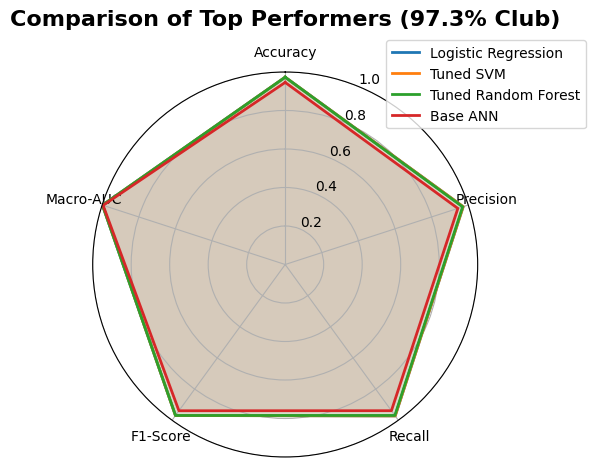

In [ ]:
# 1. Define the models and their predictions
top_models = {
    'Logistic Regression': lr_model,
    'Tuned SVM': best_svm,
    'Tuned Random Forest': best_rf,
    'Base ANN': ann_model
}

# 2. Extract metrics for each model
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Macro-AUC']
num_vars = len(metrics_labels)

# Initialize plot
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(7, 5), subplot_kw=dict(polar=True))

for name, model in top_models.items():
    # Calculate scores
    y_pred = model.predict(X_test_scaled)
    # Add +1 for XGBoost if you ever add it to this specific list

    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

    # Use the probabilities for AUC calculation
    y_prob = model.predict_proba(X_test_scaled)
    # Standard multi-class AUC logic
    auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')

    values = [acc, p, r, f, auc_score]
    values += values[:1] # Close the circle

    ax.plot(angles, values, linewidth=2, label=name)
    ax.fill(angles, values, alpha=0.1)

# 3. Formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_labels)

# Set the scale (zooming in on the 0.90 - 1.0 range)
ax.set_ylim(0, 1.0)
plt.title('Comparison of Top Performers (97.3% Club)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**4) TEST ACCURACY VS CV STABILITY**

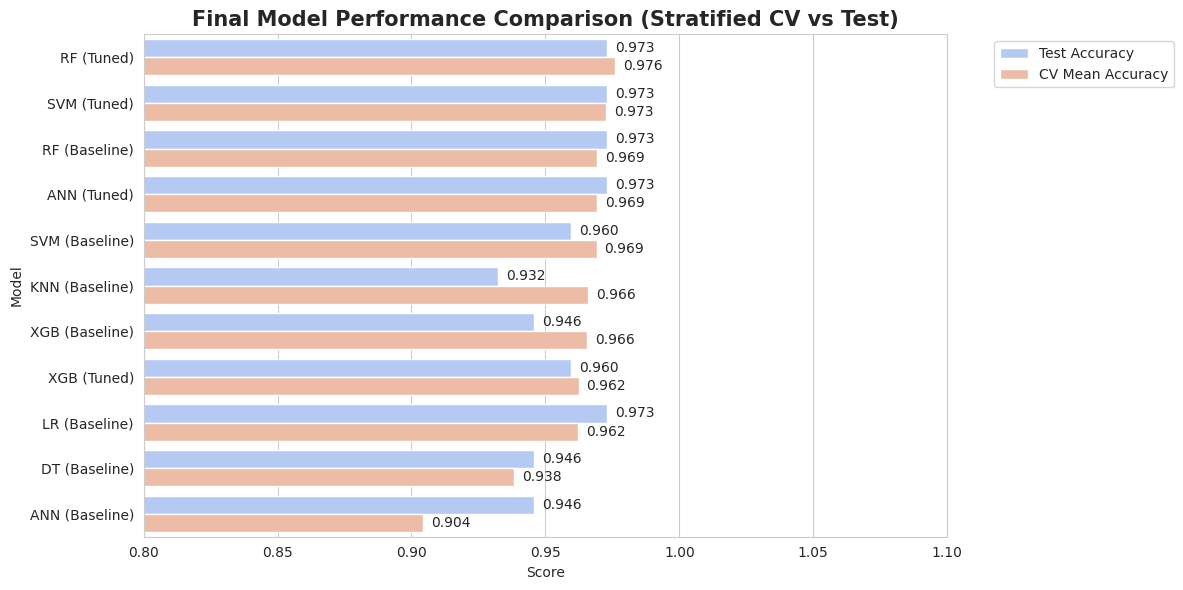

In [ ]:

plot_data = master_df[['Model', 'Test Acc', 'CV Mean']].copy()
plot_data = plot_data.rename(columns={'Test Acc': 'Test Accuracy', 'CV Mean': 'CV Mean Accuracy'})
plot_data = plot_data.melt(id_vars='Model',
                           value_vars=['Test Accuracy', 'CV Mean Accuracy'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Score', y='Model', hue='Metric', data=plot_data, palette='coolwarm')

# Adding labels to bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'center', va = 'center',
                xytext = (20, 0),
                textcoords = 'offset points')

plt.title('Final Model Performance Comparison (Stratified CV vs Test)', fontsize=15, fontweight='bold')
plt.xlim(0.8, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

***5) Final Graphical Comaprison of All Models***

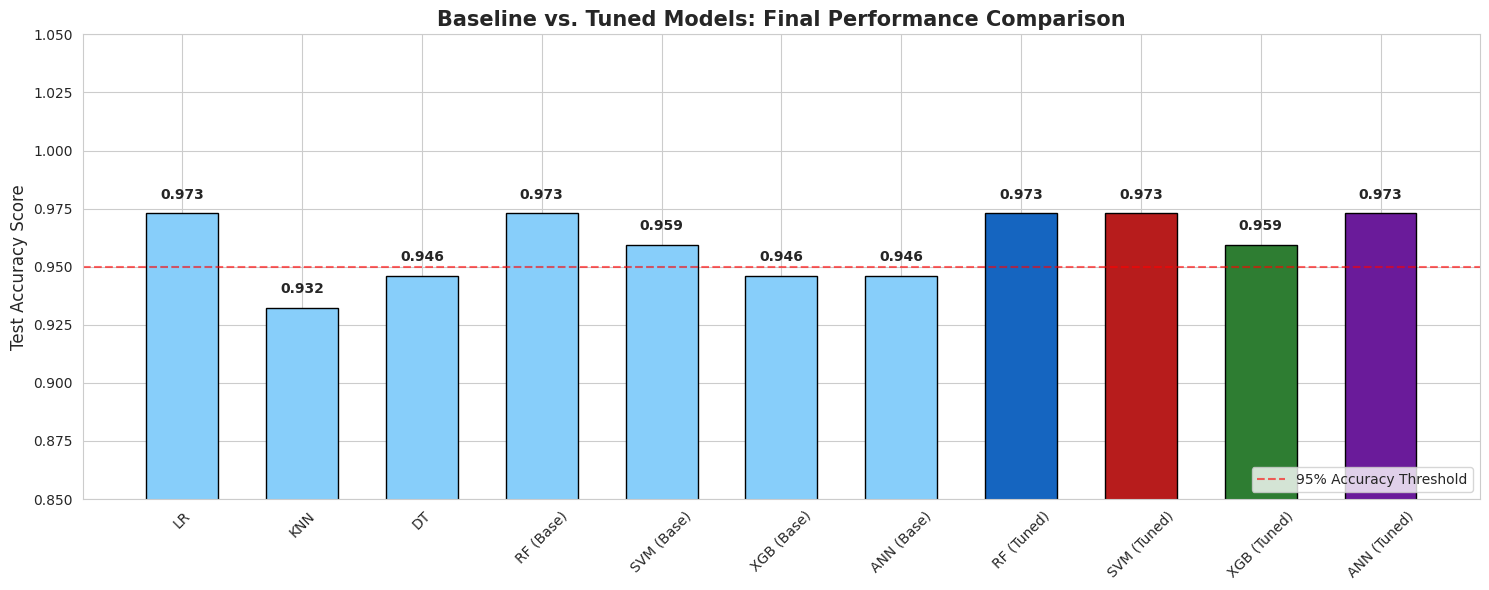

In [ ]:
# 1. Prepare data with actual distinct scores
final_comparison_data = {
    'LR': test_acc_lr,
    'KNN': test_acc_knn,
    'DT': test_acc_dt,
    'RF (Base)': test_acc_rf,
    'SVM (Base)': test_acc_svm,
    'XGB (Base)': test_acc_xgb,
    'ANN (Base)': test_acc_ann,
    'RF (Tuned)': test_acc_best_rf,    # Updated
    'SVM (Tuned)': test_acc_best_svm,  # Updated
    'XGB (Tuned)': test_acc_best_xgb,  # Updated
    'ANN (Tuned)': test_acc_best_ann   # Updated
}

labels = list(final_comparison_data.keys())
scores = list(final_comparison_data.values())

# 2. Assign specific colors to highlight the "Winners"
# Using a gradient to show baseline vs tuned
colors = ['lightskyblue']*7 + ['#1565C0', '#B71C1C', '#2E7D32', '#6A1B9A']

# 3. Create Plot
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

bars = plt.bar(labels, scores, color=colors, edgecolor='black', width=0.6)

# Add Accuracy Labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Add the 95% Threshold Line
plt.axhline(y=0.95, color='red', linestyle='--', alpha=0.6, label='95% Accuracy Threshold')

# Formatting
plt.title('Baseline vs. Tuned Models: Final Performance Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Test Accuracy Score', fontsize=12)
plt.ylim(0.85, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

## ***Best Model Selection***

The best performing model in this project is:

**`Tuned Random Forest` (class_weight='balanced')**
Best Parameters: `criterion='gini', max_depth=None, min_samples_split=5, n_estimators=100`

### Why RF (Tuned) Wins:

5 models tied at `97.30%` test accuracy (LR, RF Base, RF Tuned, ANN Tuned, SVM Tuned).
Test accuracy alone cannot break this tie — on 74 samples,
one patient changes accuracy by 1.35%.

Tie-breaking using Cross-Validation (5-Fold Stratified):

- CV Mean  : RF Tuned = 0.9760 → highest of all 11 models
- CV Std   : RF Tuned = 0.0085 → lowest of all 11 models (most stable)
- ROC-AUC  : RF Tuned = 0.9979 → highest of all 11 models

`RF (Tuned)` is simultaneously the most accurate AND most consistent model
across all data splits. For a medical diagnosis system, consistency is as
critical as peak accuracy — a model that reliably performs at 97.6%
on every fold is more trustworthy than one that scores higher sometimes
but varies more.

Final Selection: Tuned Random Forest
- CV Mean Accuracy : 0.9760 (highest)
- CV Std Deviation : ±0.0085 (lowest — most stable)
- Test Accuracy    : 0.9730
- Macro F1 Score   : 0.9694
- ROC-AUC          : 0.9979

#***DOCTOR SUGGESTIONS — TASK 3***

## **Doctor Suggestions for Early Diagnosis**

Based on the analysis of the dataset and feature importance, the following practical suggestions can help doctors in early diagnosis:

### ***Suggestion 1*** - Use Key Clinical Features First
Doctors should initially focus on important clinical features such as:
- Polygonal Papules
- Koebner Phenomenon
- Follicular Papules

These features provide strong indications of specific diseases and can reduce dependency on expensive tests.

---

### ***Suggestion 2*** - Reduce Unnecessary Biopsy Tests
If clinical symptoms clearly indicate a disease, doctors can avoid immediate biopsy and proceed with treatment.
Biopsy should be used only when diagnosis is unclear.

---

### ***Suggestion 3*** - Pay Attention to Rare Diseases
Diseases like **Pityriasis Rubra Pilaris (Class 6)** are rare and often misdiagnosed.
Doctors should carefully check for:
- Follicular Papules
- Specific histopathological features

---

### ***Suggestion 4*** - Use Age as Supporting Factor
Age can help narrow diagnosis:
- Younger patients → more likely Pityriasis Rosea
- All age groups → Psoriasis and Dermatitis

---

### ***Suggestion 5*** - Use ML Model as Decision Support Tool
The trained ML model can be used as a **support system**, not a replacement for doctors.

- High probability → strong diagnosis confidence  
- Medium probability → further testing required  
- Low probability → consider alternative diagnosis  

---

### ***Final Note :--***

Combining clinical observation with ML predictions can improve diagnosis accuracy, reduce time, and assist doctors in making faster and better decisions.

## Challenges Faced

During the development of this machine learning project, several challenges were encountered:

### ***Challenge 1*** - Missing Values in Age Column
The dataset contained missing values represented as "?" in the Age column.  
This required conversion to numeric format and handling using median imputation to avoid data loss.

---

### ***Challenge 2*** - Class Imbalance
Some diseases, especially **Pityriasis Rubra Pilaris (Class 6)**, had very few samples compared to others.  
This imbalance could affect model performance, so techniques like stratified sampling and balanced class weights were used.

---

### ***Challenge 3*** - Multicollinearity Between Features
Several features were highly correlated with each other.  
This could negatively impact model performance, so highly correlated features were identified and removed.

---

### ***Challenge 4*** - Small Dataset Size
The dataset contained only 366 records, which is relatively small for training machine learning models.  
This limits generalization and increases the risk of overfitting.

---

### ***Challenge 5*** - Model Selection and Tuning
Different models gave similar accuracy, making it challenging to select the best one.  
Hyperparameter tuning was required to identify the most stable and reliable model.

Ultimately, the Tuned Random Forest was selected based on CV Mean (0.9760) and CV Std (±0.0085) rather than test accuracy alone, since 5 models tied at 97.30%.

---

### ***Challenge 6*** - Overfitting Risk
Some models, especially complex ones like ANN and XGBoost, showed signs of overfitting.  
Techniques like cross-validation and regularization were used to control this.

---

### ***Challenge 7*** - Data Preprocessing Complexity
Handling missing values, scaling features, and ensuring no data leakage required careful implementation to maintain model accuracy.

---


### ***Challenge 8*** — Hyperparameter Tuning Did Not Always Improve Performance

In some cases, tuning actually reduced performance. XGBoost (Tuned) scored
a lower CV Mean (0.9624) than XGBoost (Baseline) (0.9657). This happens
because GridSearchCV can overfit to the specific fold structure during the
search — the best parameters found during tuning don't always generalise
to new data. This reinforces why CV scores must be reported alongside
test accuracy.

---
### ***Final Note :***

Despite these challenges, appropriate preprocessing techniques and model tuning helped achieve high accuracy and reliable performance.